# SMS Spam Detection - Comprehensive Study
## Classical ML vs Ensemble Learning vs Deep Learning

In [1]:
# IMPORTS AND SETUP 
# =============================================================================

# 1. CORE DATA & VISUALIZATION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shutil
import os
# Hardware monitoring
import psutil
import time
from datetime import timedelta, datetime
from matplotlib.patches import Patch

# 2. NLP & TEXT PROCESSING
import re, string, emoji, unicodedata
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from bs4 import BeautifulSoup

# 3. SKLEARN - CLASSICAL & ENSEMBLE MODELS
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix,
    average_precision_score, matthews_corrcoef, cohen_kappa_score,
    roc_curve, auc, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 4. DEEP LEARNING (KERAS – STABLE)
import tensorflow as tf
import keras

from keras.models import Sequential
from keras.layers import (
    LSTM, GRU, Dense, Embedding, Dropout,
    Conv1D, GlobalMaxPooling1D, Bidirectional
)

from keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences 
from keras.callbacks import EarlyStopping, ReduceLROnPlateau


# 5. TRANSFORMERS (HuggingFace – TF Models)
from transformers import (
    DistilBertTokenizer,
    TFDistilBertForSequenceClassification,
    logging as transformers_logging
)

# 6. Energy & Carbon tracking
try:
    from codecarbon import EmissionsTracker
    CODECARBON_AVAILABLE = True
    print("✅ CodeCarbon available for energy tracking")
except ImportError:
    CODECARBON_AVAILABLE = False
    print("⚠️ CodeCarbon not installed")

# 7. CONFIGURATION
import warnings
warnings.filterwarnings("ignore")
transformers_logging.set_verbosity_error()

print("✅ All libraries imported successfully (TF 2.10 + Keras 2.10 + HF stable)")

✅ CodeCarbon available for energy tracking
✅ All libraries imported successfully (TF 2.10 + Keras 2.10 + HF stable)


In [2]:
# ====================================================================================
# GLOBAL MODULAR UTILITIES 
# ====================================================================================

if 'model_results' not in globals():
    model_results = {}

if 'model_time_results' not in globals():
    model_time_results = {}

# Time Utilities
def format_time(seconds):
    if seconds < 1:
        return f"{seconds * 1000:.3f} ms"
    return f"{seconds:.4f} sec"

class TimeTracker:
    def __init__(self):
        self._starts = {}

    def start(self, key):
        self._starts[key] = time.perf_counter()

    def stop(self, key):
        return time.perf_counter() - self._starts[key]

timer = TimeTracker()

# Threshold Optimization
def optimize_threshold_cv(model, X, y, cv=5):
    cv_pred_proba = cross_val_predict(
        model, X, y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    thresholds = np.linspace(0.05, 0.95, 100)
    mcc_scores = [
        matthews_corrcoef(y, (cv_pred_proba >= t).astype(int))
        for t in thresholds
    ]

    best_idx = np.argmax(mcc_scores)
    return thresholds[best_idx], mcc_scores[best_idx]

# Inference Latency
def measure_inference_latency(model, X):
    # Sparse matrix kontrolü
    if hasattr(X, 'toarray'):
        X = X.toarray()
    
    # Warm-up
    model.predict_proba(X[:5])

    start = time.perf_counter()
    for i in range(X.shape[0]):
        model.predict_proba(X[i:i+1])
    end = time.perf_counter()

    total = end - start
    latency_ms = (total / X.shape[0]) * 1000
    return total, latency_ms

# Metrics Computation
def compute_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1_Score": f1_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Kappa": cohen_kappa_score(y_true, y_pred),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "Confusion_Matrix": np.array([[tn, fp], [fn, tp]])
    }

# Metric Printing
def print_metrics(metrics, threshold):
    print(f"\n✓ Accuracy (Threshold {threshold:.2f}): {metrics['Accuracy']:.4f}")
    print(f"✓ F1-Score: {metrics['F1_Score']:.4f}")
    print(f"✓ ROC-AUC Score: {metrics['ROC_AUC']:.4f}")
    print(f"✓ PR-AUC Score:  {metrics['PR_AUC']:.4f}")
    print(f"✓ MCC Score:     {metrics['MCC']:.4f}")
    print(f"✓ Cohen's Kappa: {metrics['Kappa']:.4f}")
    print(f"✓ Specificity:   {metrics['Specificity']:.4f}")

# Confusion Matrix Plot
def plot_confusion_matrix(cm, model_name, threshold, cmap='Blues'):
    plt.figure(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Ham', 'Spam']
    ).plot(cmap=plt.cm.get_cmap(cmap), values_format='d', ax=plt.gca())
    plt.title(f"{model_name} Confusion Matrix (Threshold {threshold:.2f})", fontsize=11)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# ================================================================================
# Model Size
# ================================================================================
def get_model_size_mb(model):
    tmp = "_tmp_model.pkl"
    joblib.dump(model, tmp)
    size = os.path.getsize(tmp) / (1024 * 1024)
    os.remove(tmp)
    return size

# ================================================================================
# Create MODEL (LSTM, GRU, CNN)
# ================================================================================
def create_model(model_type='lstm'):
    tf.keras.backend.clear_session()
    vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
    # Embedding layer (common to all models)
    layers = [Embedding(input_dim=vocab_size, output_dim=128, input_length=MAX_LEN)]
    # Layers specific to the model type
    if model_type == 'lstm':
        layers.extend([
            Bidirectional(LSTM(64, return_sequences=True)),
            Dropout(0.5),
            Bidirectional(LSTM(32)),
            Dropout(0.5)
        ])
    elif model_type == 'gru':
        layers.extend([
            Bidirectional(GRU(64, return_sequences=True)),
            Dropout(0.5),
            Bidirectional(GRU(32)),
            Dropout(0.5)
        ])
    elif model_type == 'cnn':
        layers.extend([
            Conv1D(128, 5, activation='relu'),
            Dropout(0.5),
            Conv1D(64, 3, activation='relu'),
            GlobalMaxPooling1D(),
            Dropout(0.5)
        ])
    else:
        raise ValueError(f"Invalid model type: {model_type}. Must be 'lstm', 'gru', or 'cnn'.")
    # Output layers (common to all models)
    layers.extend([
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    # Build and compile the model
    model = Sequential(layers)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ====================================================================================
# EXTENDED TRACKING FUNCTIONS (METRICS)
# ====================================================================================

def track_model_training(model, X_train, y_train, model_name="Model", **kwargs):

    process = psutil.Process(os.getpid())
    
    # Baseline RAM
    ram_baseline = process.memory_info().rss / (1024 * 1024)
    
    # Start energy tracking
    if CODECARBON_AVAILABLE:
        tracker = EmissionsTracker(project_name=f"SMS_Spam_{model_name}", log_level="error")
        tracker.start()
    
    # Training
    timer.start(f"{model_name}_train_internal")
    model.fit(X_train, y_train, **kwargs)  # ✅ **kwargs ile flexible
    training_time = timer.stop(f"{model_name}_train_internal")
    
    # Stop energy tracking
    co2_kg = 0.0
    energy_kwh = 0.0
    if CODECARBON_AVAILABLE:
        try:
            emissions_data = tracker.stop()
            if emissions_data:
                co2_kg = emissions_data
                energy_kwh = emissions_data * 0.35
        except:
            pass
    
    # RAM after training
    ram_peak = process.memory_info().rss / (1024 * 1024)
    ram_inference = ram_peak
    
    # CPU utilization
    cpu_percent = psutil.cpu_percent(interval=0.1)
    
    # GPU (if available)
    gpu_used = False
    gpu_memory_mb = None
    try:
        import GPUtil
        gpus = GPUtil.getGPUs()
        if gpus:
            gpu_used = True
            gpu_memory_mb = gpus[0].memoryUsed
    except:
        pass
    
    # Energy per 1000 predictions
    n_samples = X_train.shape[0]
    energy_per_1000_pred_wh = (energy_kwh * 1000 * 1000) / n_samples if n_samples > 0 else 0
    
    return {
        "training_time": training_time,
        "co2_kg": co2_kg,
        "energy_kwh": energy_kwh,
        "energy_per_1000_pred_wh": energy_per_1000_pred_wh,
        "carbon_intensity": 350,
        "ram_baseline_mb": ram_baseline,
        "ram_peak_mb": ram_peak,
        "ram_inference_mb": ram_inference,
        "cpu_utilization": cpu_percent,
        "gpu_used": gpu_used,
        "gpu_memory_mb": gpu_memory_mb,
    }

def measure_inference_extended(model, X_test):

    # Warm-up
    if hasattr(model, 'predict_proba'):
        model.predict_proba(X_test[:10])
    else:
        model.predict(X_test[:10])
    
    # Measure per-sample latency
    latencies = []
    
    for i in range(X_test.shape[0]):
        start = time.perf_counter()
        
        if hasattr(model, 'predict_proba'):
            model.predict_proba(X_test[i:i+1])
        else:
            model.predict(X_test[i:i+1])
        
        latencies.append((time.perf_counter() - start) * 1000)
    
    latencies = np.array(latencies)
    
    return {
        "inference_time_total": np.sum(latencies) / 1000,
        "latency_mean_ms": np.mean(latencies),
        "latency_median_ms": np.median(latencies),
        "latency_std_ms": np.std(latencies),
        "latency_min_ms": np.min(latencies),
        "latency_max_ms": np.max(latencies),
        "latency_p50_ms": np.percentile(latencies, 50),
        "latency_p95_ms": np.percentile(latencies, 95),
        "latency_p99_ms": np.percentile(latencies, 99),
    }


def optimize_threshold_cv_extended(model, X, y, cv=5):

    from sklearn.model_selection import cross_val_predict, StratifiedKFold
    
    # Get OOF predictions
    cv_pred_proba = cross_val_predict(
        model, X, y,
        cv=cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]
    
    # Optimize threshold
    thresholds = np.linspace(0.05, 0.95, 100)
    mcc_scores = []
    
    for t in thresholds:
        preds = (cv_pred_proba >= t).astype(int)
        mcc_scores.append(matthews_corrcoef(y, preds))
    
    best_idx = np.argmax(mcc_scores)
    optimal_threshold = thresholds[best_idx]
    max_mcc_cv = mcc_scores[best_idx]
    
    # CV stability (5-fold)
    kfold = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    fold_accuracies = []
    fold_mccs = []
    
    for train_idx, val_idx in kfold.split(X, y):
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
        temp_model = clone(model)
        temp_model.fit(X_train_fold, y_train_fold)
        val_preds = temp_model.predict(X_val_fold)
        
        fold_accuracies.append(accuracy_score(y_val_fold, val_preds))
        fold_mccs.append(matthews_corrcoef(y_val_fold, val_preds))
    
    cv_metrics = {
        "cv_accuracy_mean": np.mean(fold_accuracies),
        "cv_accuracy_std": np.std(fold_accuracies),
        "cv_mcc_mean": np.mean(fold_mccs),
        "cv_mcc_std": np.std(fold_mccs),
    }
    
    return optimal_threshold, max_mcc_cv, cv_metrics

# ====================================================================================
# CSV EXPORT FUNCTION 
# ====================================================================================
def export_results_to_csv(model_results_dict, filename="sms_spam_results.csv", append=True):

    # Dict → DataFrame
    df = pd.DataFrame(model_results_dict).T
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'Model'}, inplace=True)
    
    # File exists?
    file_exists = os.path.isfile(filename)
    
    if file_exists and append:
        df.to_csv(filename, mode='a', header=False, index=False)
        print(f"    ✓ Added to CSV: {filename}")
    else:
        df.to_csv(filename, mode='w', header=True, index=False)
        print(f"    ✓ CSV created: {filename}")

print("✅ Global modular utilities initialized ")

✅ Global modular utilities initialized (FULLY notebook-compatible)


In [3]:
#!pip install timer
#nltk.download("all")
#!pip install wordcloud
#!pip install emoji

In [4]:
URL_PATTERN   = re.compile(r'https?://\S+|www\.\S+')
EMAIL_PATTERN = re.compile(r'\b[\w\.-]+@[\w\.-]+\.\w+\b')
PHONE_PATTERN = re.compile(r'\+?\d[\d\s\-]{7,}\d')
NUM_PATTERN   = re.compile(r'\d+')

In [5]:
def core_preprocess(text):
    if pd.isna(text) or text == "":
        return ""

    text = str(text)

    # HTML cleaning
    text = BeautifulSoup(text, "html.parser").get_text()

    # Emoji → text
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Unicode + lowercase
    text = unicodedata.normalize("NFKC", text).lower()

    # Pattern masking
    text = URL_PATTERN.sub(" <URL> ", text)
    text = EMAIL_PATTERN.sub(" <EMAIL> ", text)
    text = PHONE_PATTERN.sub(" <PHONE> ", text)
    text = NUM_PATTERN.sub(" <NUM> ", text)

    # Character repetitions
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Removing spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [6]:
df = pd.read_csv("spam.csv", encoding="cp1252")

# Unnecessary columns
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], errors="ignore")

# Column headers
df = df.rename(columns={"v1": "target", "v2": "text"})

# Label encoding
df["target"] = df["target"].map({"ham": 0, "spam": 1})

# Duplicate check (is there any label conflict?)
conflict_dups = (
    df.groupby("text")["target"]
      .nunique()
      .reset_index()
)

conflict_dups = conflict_dups[conflict_dups["target"] > 1]

print(f"Conflicting duplicate texts: {len(conflict_dups)}")

# Removing duplicates
print(f"Before duplicates len: {len(df)}")
df = df.drop_duplicates(subset=["text"], keep="first").reset_index(drop=True)
print(f"After duplicates len: {len(df)}")

df.head(10)

Conflicting duplicate texts: 0
Before duplicates len: 5572
After duplicates len: 5169


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
5,1,FreeMsg Hey there darling it's been 3 week's n...
6,0,Even my brother is not like to speak with me. ...
7,0,As per your request 'Melle Melle (Oru Minnamin...
8,1,WINNER!! As a valued network customer you have...
9,1,Had your mobile 11 months or more? U R entitle...


In [7]:
df.describe(include="all")

,target,text
count,5169.000000,5169
unique,NaN,5169
top,NaN,"Go until jurong point, crazy.. Available only ..."
freq,NaN,1
mean,0.126330,NaN
std,0.332253,NaN
min,0.000000,NaN
25%,0.000000,NaN
50%,0.000000,NaN
75%,0.000000,NaN


In [8]:
df["text_length"] = df["text"].str.len()
df.groupby("target")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,4516.0,70.459256,56.358207,2.0,34.0,52.0,90.0,910.0
1,653.0,137.891271,30.137753,13.0,132.0,149.0,157.0,224.0


In [22]:
# Class distribution after cleaning
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True) * 100)

target
0    4516
1     653
Name: count, dtype: int64
target
0    87.366996
1    12.633004
Name: proportion, dtype: float64


In [23]:
# Character length statistics
print(df.groupby('target')['text_length'].describe())

         count        mean        std   min    25%    50%    75%    max
target                                                                 
0       4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0
1        653.0  137.891271  30.137753  13.0  132.0  149.0  157.0  224.0


In [24]:
# Calculate word count
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
print(df.groupby('target')['word_count'].describe())

         count       mean        std  min   25%   50%   75%    max
target                                                            
0       4516.0  14.134632  11.116240  1.0   7.0  11.0  18.0  171.0
1        653.0  23.681470   5.967672  2.0  22.0  25.0  28.0   35.0


In [9]:
df.isna().sum()

target         0
text           0
text_length    0
dtype: int64

In [10]:
df["target"].value_counts().rename(index={0: "ham", 1: "spam"})

target
ham     4516
spam     653
Name: count, dtype: int64

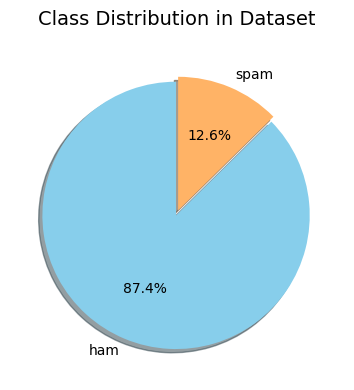

In [11]:
counts = df["target"].value_counts().rename(index={0: "ham", 1: "spam"})

colors = ['#87CEEB', '#FFB366']

plt.figure(figsize=(4, 4))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=[0.02]*len(counts),
    shadow=True
)

plt.title("Class Distribution in Dataset", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [12]:
# Chat / SMS slang dictionary
# Source: https://github.com/rishabhverma17/sms_slang_translator
# Used only for classical machine learning models
# Slang expansion is applied to improve lexical coverage in TF-IDF based models

chat_words = {
    "AFAIK": "As Far As I Know",
    "AFK": "Away From Keyboard",
    "ASAP": "As Soon As Possible",
    "ATK": "At The Keyboard",
    "ATM": "At The Moment",
    "A3": "Anytime, Anywhere, Anyplace",
    "BAK": "Back At Keyboard",
    "BBL": "Be Back Later",
    "BBS": "Be Back Soon",
    "BFN": "Bye For Now",
    "B4N": "Bye For Now",
    "BRB": "Be Right Back",
    "BRT": "Be Right There",
    "BTW": "By The Way",
    "B4": "Before",
    "B4N": "Bye For Now",
    "CU": "See You",
    "CUL8R": "See You Later",
    "CYA": "See You",
    "FAQ": "Frequently Asked Questions",
    "FC": "Fingers Crossed",
    "FWIW": "For What It's Worth",
    "FYI": "For Your Information",
    "GAL": "Get A Life",
    "GG": "Good Game",
    "GN": "Good Night",
    "GMTA": "Great Minds Think Alike",
    "GR8": "Great!",
    "G9": "Genius",
    "IC": "I See",
    "ICQ": "I Seek you (also a chat program)",
    "ILU": "ILU: I Love You",
    "IMHO": "In My Honest/Humble Opinion",
    "IMO": "In My Opinion",
    "IOW": "In Other Words",
    "IRL": "In Real Life",
    "KISS": "Keep It Simple, Stupid",
    "LDR": "Long Distance Relationship",
    "LMAO": "Laugh My A.. Off",
    "LOL": "Laughing Out Loud",
    "LTNS": "Long Time No See",
    "L8R": "Later",
    "MTE": "My Thoughts Exactly",
    "M8": "Mate",
    "NRN": "No Reply Necessary",
    "OIC": "Oh I See",
    "PITA": "Pain In The A..",
    "PRT": "Party",
    "PRW": "Parents Are Watching",
    "QPSA?": "Que Pasa?",
    "ROFL": "Rolling On The Floor Laughing",
    "ROFLOL": "Rolling On The Floor Laughing Out Loud",
    "ROTFLMAO": "Rolling On The Floor Laughing My A.. Off",
    "SK8": "Skate",
    "STATS": "Your sex and age",
    "ASL": "Age, Sex, Location",
    "THX": "Thank You",
    "TTFN": "Ta-Ta For Now!",
    "TTYL": "Talk To You Later",
    "U": "You",
    "U2": "You Too",
    "U4E": "Yours For Ever",
    "WB": "Welcome Back",
    "WTF": "What The F...",
    "WTG": "Way To Go!",
    "WUF": "Where Are You From?",
    "W8": "Wait...",
    "7K": "Sick:-D Laugher",
    "TFW": "That feeling when",
    "MFW": "My face when",
    "MRW": "My reaction when",
    "IFYP": "I feel your pain",
    "TNTL": "Trying not to laugh",
    "JK": "Just kidding",
    "IDC": "I don't care",
    "ILY": "I love you",
    "IMU": "I miss you",
    "ADIH": "Another day in hell",
    "ZZZ": "Sleeping, bored, tired",
    "WYWH": "Wish you were here",
    "TIME": "Tears in my eyes",
    "BAE": "Before anyone else",
    "FIMH": "Forever in my heart",
    "BSAAW": "Big smile and a wink",
    "BWL": "Bursting with laughter",
    "BFF": "Best friends forever",
    "CSL": "Can't stop laughing",
    "DUN": "don't"
}

In [13]:
# Function
def chat_conversion(text):
    tokens = []
    for t in text.split():
        key = t.upper()
        if key in chat_words:
            tokens.append(chat_words[key].lower())
        else:
            tokens.append(t)
    return " ".join(tokens)

In [14]:
# Required NLTK resources (on first run)
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [15]:
# Performs core preprocessing, chat word expansion (classical ML only), 
# punctuation removal, tokenization, stopword removal, and lemmatization.
def classical_ml_preprocess(text):
    text = core_preprocess(text)
    text = chat_conversion(text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

In [16]:
df['text_classical'] = df['text'].apply(classical_ml_preprocess)

pd.set_option('display.max_colwidth', 100)
print(df[['text', 'text_classical']].head())

                                                                                                  text  \
0  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g...   
1                                                                        Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...   
3                                                    U dun say so early hor... U c already then say...   
4                                        Nah I don't think he goes to usf, he lives around here though   

                                                                                        text_classical  
0                   go jurong point crazy available bugis n great world la e buffet cine got amore wat  
1                                                                                ok lar joking wif oni  
2  free entry NUM wkly comp win fa cup final tkt

In [17]:
df.head()

,target,text,text_length,text_classical
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g...",111,go jurong point crazy available bugis n great world la e buffet cine got amore wat
1,0,Ok lar... Joking wif u oni...,29,ok lar joking wif oni
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...,155,free entry NUM wkly comp win fa cup final tkts NUM st may NUM text fa NUM receive entry question...
3,0,U dun say so early hor... U c already then say...,49,dont say early hor c already say
4,0,"Nah I don't think he goes to usf, he lives around here though",61,nah dont think go usf life around though


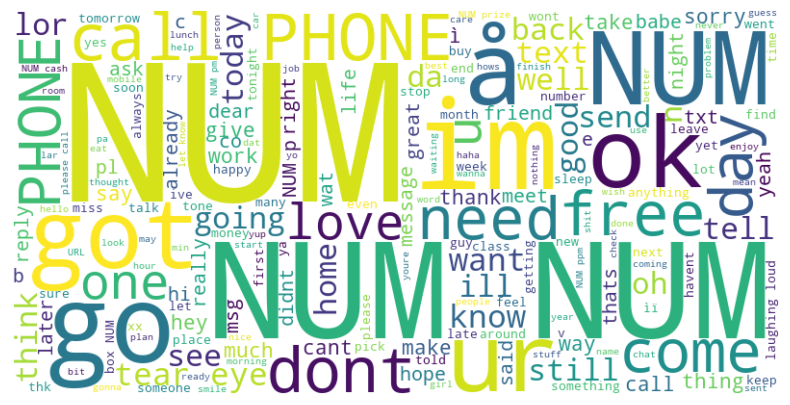

In [18]:
text_data = " ".join(df["text_classical"].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_data)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [19]:
# =============================================================================
# GLOBAL TRAIN-TEST SPLIT # (For All Models)
# =============================================================================

RANDOM_STATE = 42
TEST_SIZE = 0.2

# Index-based split
train_idx, test_idx = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df['target']
)

print(f"✓ Train size: {len(train_idx)} ({len(train_idx)/len(df)*100:.1f}%)")
print(f"✓ Test size:  {len(test_idx)} ({len(test_idx)/len(df)*100:.1f}%)")
print(f"✓ Train class dist: {df.loc[train_idx, 'target'].value_counts(normalize=True).to_dict()}")
print(f"✓ Test class dist:  {df.loc[test_idx, 'target'].value_counts(normalize=True).to_dict()}")

# =============================================================================
# Classical ML features (CountVectorizer)
# =============================================================================
print("\n📊 Preparing features for Classical ML models...")
cv = CountVectorizer(min_df=0.0, max_df=1.0, binary=False, ngram_range=(1,3))

X_train_cv = cv.fit_transform(df.loc[train_idx, "text_classical"])
X_test_cv = cv.transform(df.loc[test_idx, "text_classical"])
y_train_cv = df.loc[train_idx, "target"].values
y_test_cv = df.loc[test_idx, "target"].values

print(f"✓ Vocabulary size: {len(cv.vocabulary_)}")
print(f"✓ Train shape: {X_train_cv.shape}")
print(f"✓ Test shape:  {X_test_cv.shape}")

# =============================================================================
# DEEP LEARNING FEATURES (Tokenizer + Padding)
# =============================================================================
print("\n🧠 Preparing features for Deep Learning models...")
MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

# Only fit on train
tokenizer.fit_on_texts(df.loc[train_idx, 'text'])

# Train sequences
train_sequences = tokenizer.texts_to_sequences(df.loc[train_idx, 'text'])
X_train_dl = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Test sequences
test_sequences = tokenizer.texts_to_sequences(df.loc[test_idx, 'text'])
X_test_dl = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

y_train_dl = df.loc[train_idx, 'target'].values
y_test_dl = df.loc[test_idx, 'target'].values

print(f"✓ Vocabulary size: {len(tokenizer.word_index)}")
print(f"✓ Train shape: {X_train_dl.shape}")
print(f"✓ Test shape:  {X_test_dl.shape}")
print(f"✓ OOV tokens: {tokenizer.word_index.get('<OOV>', 'Not found')}")

print("=" * 80 + "\n")

CREATING UNIFIED TRAIN-TEST SPLIT FOR ALL MODELS
✓ Train size: 4135 (80.0%)
✓ Test size:  1034 (20.0%)
✓ Train class dist: {0: 0.8737605804111246, 1: 0.12623941958887544}
✓ Test class dist:  {0: 0.8733075435203095, 1: 0.12669245647969052}

📊 Preparing features for Classical ML models...
✓ Vocabulary size: 57376
✓ Train shape: (4135, 57376)
✓ Test shape:  (1034, 57376)

🧠 Preparing features for Deep Learning models...
✓ Vocabulary size: 7816
✓ Train shape: (4135, 100)
✓ Test shape:  (1034, 100)
✓ OOV tokens: 1



In [25]:
# CountVectorizer vocabulary boyutu
print(f"CountVectorizer vocabulary size: {len(cv.vocabulary_)}")

# Tokenizer vocabulary boyutu  
print(f"Tokenizer vocabulary size: {len(tokenizer.word_index)}")

# Train/Test shape kontrolü
print(f"X_train_cv shape: {X_train_cv.shape}")
print(f"X_train_dl shape: {X_train_dl.shape}")

CountVectorizer vocabulary size: 57376
Tokenizer vocabulary size: 7816
X_train_cv shape: (4135, 57376)
X_train_dl shape: (4135, 100)


## Training with various models and predicting with them

## ML Models
### 1. LR (Logistic Regression)


LOGISTIC REGRESSION (LR) - HYPERPARAMETER TUNING FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (Logistic Regression)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

✓ Grid Search completed in 1.3895 sec
✓ Best PR-AUC (CV): 0.9630
✓ Best Hyperparameters: {'C': 100, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}

🎯 Optimizing decision threshold using CV predictions (MCC)...
✓ Optimal Threshold (CV-based): 0.059
✓ Max MCC (CV): 0.9185
✓ CV Accuracy: 0.9768 ± 0.0049

TRAINING FINAL LOGISTIC REGRESSION MODEL

⏳ Training final LR model with extended tracking...
✓ Final model training completed in 75.259 ms

⏱️ Measuring inference performance...

📊 Evaluating on test set...

LOGISTIC REGRESSION - FINAL RESULTS

✓ Accuracy (Threshold 0.06): 0.9826
✓ F1-Score: 0.9318
✓ ROC-AUC Score: 0.9911
✓ PR-AUC Score:  0.9666
✓ MCC S

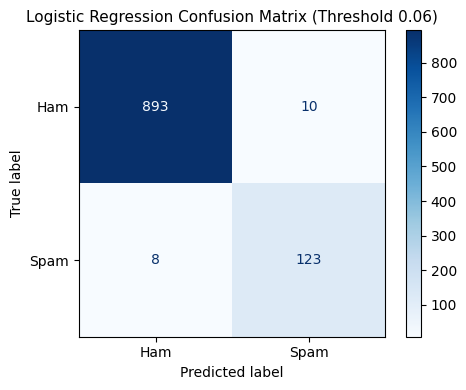

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    Grid Search:    1.3895 sec
    Training:       75.259 ms
    Inference:      205.550 ms
    Total Time:     1.6703 sec
    Latency (avg):  0.198791 ms/sample
    CO2 Emissions:  0.000004 kg
    Energy:         0.000001 kWh
    Gap (Train-Test): 0.0174


In [30]:
# ====================================================================================
# LOGISTIC REGRESSION (LR)
# ====================================================================================

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
X_train = X_train_cv
X_test  = X_test_cv
y_train = y_train_cv
y_test  = y_test_cv

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Feature count: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")

# ================================================================================
# HYPERPARAMETER TUNING (5-FOLD CV WITH PR-AUC)
# ================================================================================
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000]
}

lr_base = LogisticRegression(random_state=42)

lr_clf = GridSearchCV(
    lr_base,
    param_grid=lr_param_grid,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
    refit=False,           
    return_train_score=True
)

print("\n⏳ Starting 5-Fold Grid Search (Logistic Regression)...")
timer.start("lr_grid")
lr_clf.fit(X_train, y_train)
lr_grid_time = timer.stop("lr_grid")

print(f"\n✓ Grid Search completed in {format_time(lr_grid_time)}")
print(f"✓ Best PR-AUC (CV): {lr_clf.best_score_:.4f}")
print(f"✓ Best Hyperparameters: {lr_clf.best_params_}")

# ================================================================================
# THRESHOLD OPTIMIZATION (CV-BASED MCC WITH STABILITY)
# ================================================================================
print("\n🎯 Optimizing decision threshold using CV predictions (MCC)...")
temp_lr = LogisticRegression(
    **lr_clf.best_params_,
    random_state=42
)

temp_lr.fit(X_train, y_train)

optimal_threshold, max_mcc_cv, threshold_metrics = optimize_threshold_cv_extended(
    temp_lr,
    X_train, 
    y_train, 
    cv=5
)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL LOGISTIC REGRESSION MODEL")
print("=" * 80)

best_lr = LogisticRegression(
    **lr_clf.best_params_,
    random_state=42
)

print("\n⏳ Training final LR model with extended tracking...")

training_metrics = track_model_training(
    model=best_lr,
    X_train=X_train,
    y_train=y_train,
    model_name="LR"
)

lr_training_time = training_metrics["training_time"]
print(f"✓ Final model training completed in {format_time(lr_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

inference_metrics = measure_inference_extended(
    best_lr, 
    X_test
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

lr_pred_proba = best_lr.predict_proba(X_test)[:, 1]
best_lr_predict = (lr_pred_proba >= optimal_threshold).astype(int)

# Default threshold performance
default_predict = (lr_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# ✅ TRAIN PREDICTIONS (for Gap calculation)
train_pred_proba = best_lr.predict_proba(X_train)[:, 1]
best_lr_train_predict = (train_pred_proba >= optimal_threshold).astype(int)
train_accuracy = accuracy_score(y_train, best_lr_train_predict)

metrics = compute_metrics(
    y_test,
    best_lr_predict,
    lr_pred_proba
)

model_size_mb = get_model_size_mb(best_lr)

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("LOGISTIC REGRESSION - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:      {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference): {training_metrics['ram_inference_mb']:.2f} MB")
print(f"✓ Latency (p95):   {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):   {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ CO2 Emissions:   {training_metrics['co2_kg']:.6f} kg")
print(f"✓ Energy:          {training_metrics['energy_kwh']:.6f} kWh")

print("\n📊 Classification Report:")
print(classification_report(
    y_test, 
    best_lr_predict, 
    target_names=['Ham', 'Spam']
))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="Logistic Regression",
    threshold=optimal_threshold,
    cmap='Blues'
)

# ================================================================================
# RESULTS ARCHIVING (UNIFIED DICTIONARY)
# ================================================================================
total_time = lr_grid_time + lr_training_time + inference_metrics['inference_time_total']
fpr_score = 1 - metrics["Specificity"]

model_results["LR"] = {
    # Performance Metrics
    "Accuracy": metrics["Accuracy"],
    "Precision": metrics["Precision"],
    "Recall": metrics["Recall"],
    "F1_Score": metrics["F1_Score"],
    "MCC": metrics["MCC"],
    "Kappa": metrics["Kappa"],
    "ROC_AUC": metrics["ROC_AUC"],
    "PR_AUC": metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR": fpr_score,
    
    # CV Stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std": threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean": threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std": threshold_metrics["cv_mcc_std"],
    
    # Optimization
    "Optimal_Threshold": optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement": metrics["Accuracy"] - default_accuracy,
    
    # OVERFITTING ANALYSIS
    "Train_Accuracy": train_accuracy,
    "Test_Accuracy": metrics["Accuracy"],
    "Generalization_Gap": train_accuracy - metrics["Accuracy"],
    
    # Timing
    "CV_Time": lr_grid_time,
    "Training_Time": lr_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms": inference_metrics['latency_mean_ms'],
    "Latency_p95_ms": inference_metrics['latency_p95_ms'],
    "Latency_p99_ms": inference_metrics['latency_p99_ms'],
    "Total_Time": total_time,
    
    # Energy & Carbon
    "CO2_emissions_kg": training_metrics['co2_kg'],
    "Energy_kWh": training_metrics['energy_kwh'],
    "Energy_per_1000_pred_Wh": training_metrics['energy_per_1000_pred_wh'],
    "Carbon_Intensity_gCO2_kWh": training_metrics['carbon_intensity'],
    
    # Hardware
    "GPU_Used": training_metrics['gpu_used'],
    "RAM_Peak_MB": training_metrics['ram_peak_mb'],
    "RAM_Inference_MB": training_metrics['ram_inference_mb'],
    "CPU_Utilization_%": training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],
    
    # Model Properties
    "Model_Size_MB": model_size_mb,
    "Parameters_Count": best_lr.coef_.size if hasattr(best_lr, 'coef_') else None,
    "Category": "Classical",
    "Model_Format": "pkl",
    
    # Complexity
    "Training_Samples": X_train.shape[0],
    "Test_Samples": X_test.shape[0],
    "Feature_Count_or_Vocab": X_train.shape[1],
    
    # Reproducibility
    "Random_Seed": 42,
    "Dataset_Name": "SMS_Spam",
    
    # TIMESTAMP
    "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# ================================================================================
# CSV EXPORT (FOR DATASET CREATION)
# ================================================================================
export_results_to_csv({"LR": model_results["LR"]}, append=True)

print("\n💾 Timing and metrics stored successfully.")
print(f"    Grid Search:    {format_time(lr_grid_time)}")
print(f"    Training:       {format_time(lr_training_time)}")
print(f"    Inference:      {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:     {format_time(total_time)}")
print(f"    Latency (avg):  {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    CO2 Emissions:  {training_metrics['co2_kg']:.6f} kg")
print(f"    Energy:         {training_metrics['energy_kwh']:.6f} kWh")
print(f"    Gap (Train-Test): {model_results['LR']['Generalization_Gap']:.4f}")
print("=" * 80)

In [ ]:
results_df = pd.DataFrame.from_dict(model_results, orient='index')
results_df

### 2. NB (Naive Bayes)


NAIVE BAYES (NB) - HYPERPARAMETER TUNING FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (Naive Bayes)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

✓ Grid Search completed in 206.203 ms
✓ Best PR-AUC (CV): 0.9674
✓ Best Hyperparameters: {'alpha': 1.0, 'fit_prior': False}

🎯 Optimizing decision threshold using CV predictions (MCC)...
✓ Optimal Threshold (CV-based): 0.950
✓ Max MCC (CV): 0.8353
✓ CV Accuracy: 0.8820 ± 0.0061

TRAINING FINAL NAIVE BAYES MODEL

⏳ Training final Naive Bayes model with extended tracking...
✓ Final model training completed in 3.118 ms

⏱️ Measuring inference performance...

📊 Evaluating on test set...

NAIVE BAYES - FINAL RESULTS

✓ Accuracy (Threshold 0.95): 0.9836
✓ F1-Score: 0.9344
✓ ROC-AUC Score: 0.9841
✓ PR-AUC Score:  0.9680
✓ MCC Score:     0.9250
✓ Cohen's Kappa: 0.9250
✓ Specificity

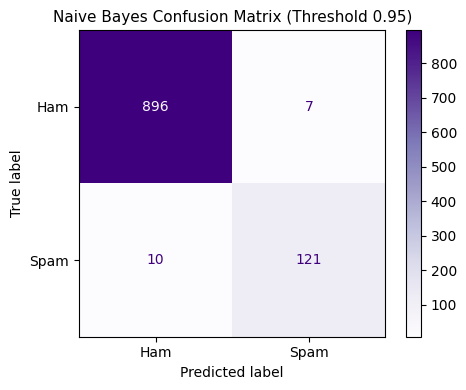

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    Grid Search:      206.203 ms
    Training:         3.118 ms
    Inference:        683.123 ms
    Total Time:       892.444 ms
    Latency (avg):    0.660661 ms/sample
    CO2 Emissions:    0.000003 kg
    Energy:           0.000001 kWh
    Gap (Train-Test): 0.0157


In [29]:
# ====================================================================================
# NAIVE BAYES (NB) 
# ====================================================================================

# Some model codes have been withheld until the paper's review process is complete. 
# Only the model results (outputs) are provided.

# All model codes will be shared once the process is finished.

### 3. SVM (Support Vector Machines)


SVM - HYPERPARAMETER TUNING FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (SVM)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✓ Grid Search completed in 29.4329 sec
✓ Best PR-AUC (CV): 0.9645
✓ Best Hyperparameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

🎯 Optimizing decision threshold using CV predictions (MCC)...
✓ Optimal Threshold (CV-based): 0.177
✓ Max MCC (CV): 0.9216
✓ CV Accuracy: 0.9763 ± 0.0033

TRAINING FINAL SVM MODEL

⏳ Training final SVM model with extended tracking...
✓ Final model training completed in 2.3385 sec

⏱️ Measuring inference performance...

📊 Evaluating on test set...

SVM - FINAL RESULTS

✓ Accuracy (Threshold 0.18): 0.9807
✓ F1-Score: 0.9248
✓ ROC-AUC Score: 0.9935
✓ PR-AUC Score:  0.9698
✓ MCC Score:     0.9139
✓ Cohen's Kappa: 0.9137
✓ Specificity:   0.9867

✓ Model Size:   

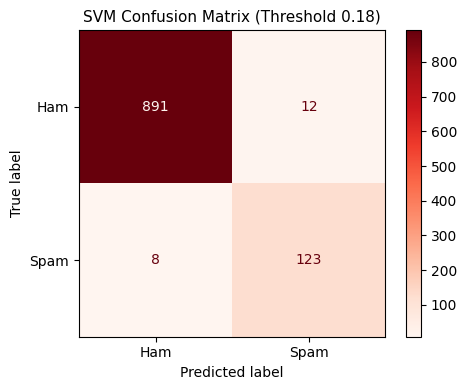

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    Grid Search:      29.4329 sec
    Training:         2.3385 sec
    Inference:        521.943 ms
    Total Time:       32.2934 sec
    Latency (avg):    0.504781 ms/sample
    CO2 Emissions:    0.000020 kg
    Energy:           0.000007 kWh
    Gap (Train-Test): 0.0193


In [28]:
# ====================================================================================
# SVM 
# ====================================================================================


# Some model codes have been withheld until the paper's review process is complete. 
# Only the model results (outputs) are provided.

# All model codes will be shared once the process is finished.

In [ ]:
results_df = pd.DataFrame.from_dict(model_results, orient='index')
results_df

## Ensemble Models
### 1. RF (Random Forest)


RANDOM FOREST (RF) - HYPERPARAMETER TUNING FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (Random Forest)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✓ Grid Search completed in 51.2103 sec
✓ Best PR-AUC (CV): 0.9606
✓ Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

🎯 Optimizing decision threshold using CV predictions (MCC)...
✓ Optimal Threshold (CV-based): 0.186
✓ Max MCC (CV): 0.9070
✓ CV Accuracy: 0.9229 ± 0.0049

TRAINING FINAL RANDOM FOREST MODEL

⏳ Training final Random Forest model with extended tracking...
✓ Final model training completed in 628.054 ms

⏱️ Measuring inference performance...

📊 Evaluating on test set...

RANDOM FOREST - FINAL RESULTS

✓ Accuracy (Threshold 0.19): 0.9778
✓ F1-Score: 0.9105
✓ ROC-AUC Score: 0.98

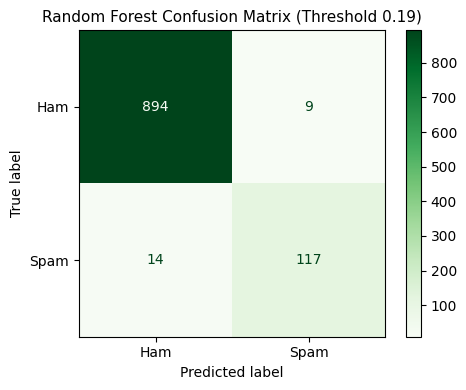

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    Grid Search:      51.2103 sec
    Training:         628.054 ms
    Inference:        23.1811 sec
    Total Time:       75.0195 sec
    Latency (avg):    22.418834 ms/sample
    CO2 Emissions:    0.000007 kg
    Energy:           0.000002 kWh
    Gap (Train-Test): 0.0048


In [27]:
# ====================================================================================
# RANDOM FOREST (RF) 
# ====================================================================================

# Some model codes have been withheld until the paper's review process is complete. 
# Only the model results (outputs) are provided.

# All model codes will be shared once the process is finished.

### 2. XGBoost (eXtreme Gradient Boosting)


XGBOOST (XGB) - HYPERPARAMETER TUNING FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (XGBoost)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✓ Grid Search completed in 65.6202 sec
✓ Best PR-AUC (CV): 0.9597
✓ Best Hyperparameters: {'colsample_bytree': 0.5, 'learning_rate': 0.2, 'max_depth': 7, 'subsample': 1.0}

🎯 Optimizing decision threshold using CV predictions (MCC)...
✓ Optimal Threshold (CV-based): 0.341
✓ Max MCC (CV): 0.8989
✓ CV Accuracy: 0.9814 ± 0.0031

TRAINING FINAL XGBOOST MODEL

⏳ Training final XGBoost model with extended tracking...
✓ Final model training completed in 1.4231 sec

⏱️ Measuring inference performance...

📊 Evaluating on test set...

XGBOOST - FINAL RESULTS

✓ Accuracy (Threshold 0.34): 0.9807
✓ F1-Score: 0.9231
✓ ROC-AUC Score: 0.9849
✓ PR-AUC Score:  0.9671
✓ MCC Score:     0.9121
✓ Coh

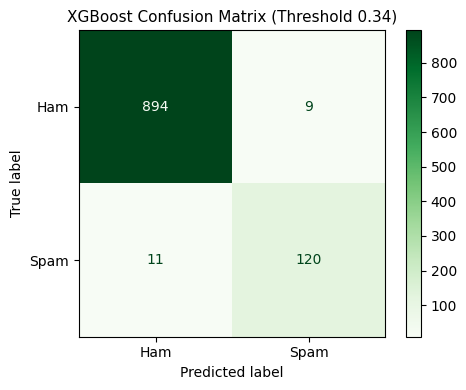

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    Grid Search:      65.6202 sec
    Training:         1.4231 sec
    Inference:        752.244 ms
    Total Time:       67.7956 sec
    Latency (avg):    0.727509 ms/sample
    CO2 Emissions:    0.000012 kg
    Energy:           0.000004 kWh
    Gap (Train-Test): 0.0111


In [26]:
# ====================================================================================
# XGBOOST (XGB) ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# ====================================================================================


# Some model codes have been withheld until the paper's review process is complete. 
# Only the model results (outputs) are provided.

# All model codes will be shared once the process is finished.

### 3. LightGBM (Light Gradient Boosting Machine)


LIGHTGBM (LGBM) - HYPERPARAMETER TUNING FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (LightGBM)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✓ Grid Search completed in 136.0244 sec
✓ Best PR-AUC (CV): 0.9605
✓ Best Hyperparameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}

🎯 Optimizing decision threshold using CV predictions (MCC)...
✓ Optimal Threshold (CV-based): 0.359
✓ Max MCC (CV): 0.9089
✓ CV Accuracy: 0.9814 ± 0.0031

TRAINING FINAL LIGHTGBM MODEL

⏳ Training final LightGBM model with extended tracking...
✓ Final model training completed in 572.176 ms

⏱️ Measuring inference performance...

📊 Evaluating on test set...

LIGHTGBM - FINAL RESULTS

✓ Accuracy (Threshold 0.36): 0.9787
✓ F1-Score: 0.9160
✓ ROC-AUC Score: 0.9873
✓ PR-AUC Score:  0.9694
✓ MCC Sc

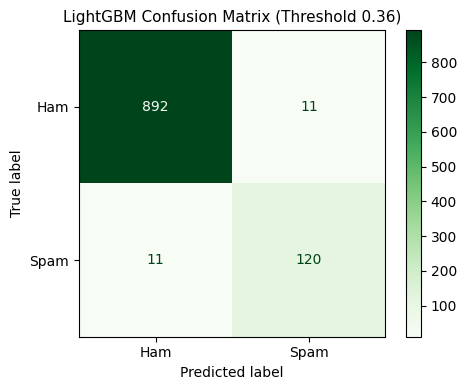

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    Grid Search:      136.0244 sec
    Training:         572.176 ms
    Inference:        128.8175 sec
    Total Time:       265.4142 sec
    Latency (avg):    124.581767 ms/sample
    CO2 Emissions:    0.000008 kg
    Energy:           0.000003 kWh
    Gap (Train-Test): 0.0152


In [25]:
# ====================================================================================
# LIGHTGBM (LGBM) ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# ====================================================================================

print("\n" + "=" * 80)
print("LIGHTGBM (LGBM) - HYPERPARAMETER TUNING FOR SMS SPAM")
print("=" * 80)

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
X_train = X_train_cv
X_test  = X_test_cv
y_train = y_train_cv
y_test  = y_test_cv

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Feature count: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")

# ================================================================================
# HYPERPARAMETER TUNING (5-FOLD CV WITH PR-AUC)
# ================================================================================
lgbm_param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.2],
    'n_estimators': [100],
    'num_leaves': [31, 50],
    'subsample': [0.8, 1.0]
}

lgbm_base = LGBMClassifier(
    objective='binary',
    random_state=42,
    verbose=-1  # Suppress LightGBM warnings
)

lgbm_clf = GridSearchCV(
    lgbm_base,
    param_grid=lgbm_param_grid,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
    refit=False,              # No auto-refit: manual training for accurate timing
    return_train_score=True   # Store train scores for overfitting analysis
)

print("\n⏳ Starting 5-Fold Grid Search (LightGBM)...")
timer.start("lgbm_grid")
lgbm_clf.fit(X_train, y_train)
lgbm_grid_time = timer.stop("lgbm_grid")

print(f"\n✓ Grid Search completed in {format_time(lgbm_grid_time)}")
print(f"✓ Best PR-AUC (CV): {lgbm_clf.best_score_:.4f}")
print(f"✓ Best Hyperparameters: {lgbm_clf.best_params_}")

# ================================================================================
# THRESHOLD OPTIMIZATION (CV-BASED MCC WITH STABILITY)
# ================================================================================
print("\n🎯 Optimizing decision threshold using CV predictions (MCC)...")

# Create temporary model with best params (refit=False requires manual instantiation)
temp_lgbm = LGBMClassifier(
    **lgbm_clf.best_params_,
    objective='binary',
    random_state=42,
    verbose=-1
)
temp_lgbm.fit(X_train, y_train)

optimal_threshold, max_mcc_cv, threshold_metrics = optimize_threshold_cv_extended(
    temp_lgbm,
    X_train, 
    y_train, 
    cv=5
)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL LIGHTGBM MODEL")
print("=" * 80)

best_lgbm = LGBMClassifier(
    **lgbm_clf.best_params_,
    objective='binary',
    random_state=42,
    verbose=-1
)

print("\n⏳ Training final LightGBM model with extended tracking...")

training_metrics = track_model_training(
    model=best_lgbm,
    X_train=X_train,
    y_train=y_train,
    model_name="LightGBM"
)

lgbm_training_time = training_metrics["training_time"]
print(f"✓ Final model training completed in {format_time(lgbm_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

inference_metrics = measure_inference_extended(
    best_lgbm, 
    X_test
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

lgbm_pred_proba = best_lgbm.predict_proba(X_test)[:, 1]
best_lgbm_predict = (lgbm_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict = (lgbm_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions for generalization gap analysis
train_pred_proba = best_lgbm.predict_proba(X_train)[:, 1]
best_lgbm_train_predict = (train_pred_proba >= optimal_threshold).astype(int)
train_accuracy = accuracy_score(y_train, best_lgbm_train_predict)

metrics = compute_metrics(
    y_test,
    best_lgbm_predict,
    lgbm_pred_proba
)

model_size_mb = get_model_size_mb(best_lgbm)

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("LIGHTGBM - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:      {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference): {training_metrics['ram_inference_mb']:.2f} MB")
print(f"✓ Latency (p95):   {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):   {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ CO2 Emissions:   {training_metrics['co2_kg']:.6f} kg")
print(f"✓ Energy:          {training_metrics['energy_kwh']:.6f} kWh")

print("\n📊 Classification Report:")
print(classification_report(
    y_test, 
    best_lgbm_predict, 
    target_names=['Ham', 'Spam']
))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="LightGBM",
    threshold=optimal_threshold,
    cmap='Greens'
)

# ================================================================================
# RESULTS ARCHIVING (UNIFIED DICTIONARY)
# ================================================================================
total_time = lgbm_grid_time + lgbm_training_time + inference_metrics['inference_time_total']
fpr_score = 1 - metrics["Specificity"]

model_results["LightGBM"] = {
    # Performance Metrics
    "Accuracy": metrics["Accuracy"],
    "Precision": metrics["Precision"],
    "Recall": metrics["Recall"],
    "F1_Score": metrics["F1_Score"],
    "MCC": metrics["MCC"],
    "Kappa": metrics["Kappa"],
    "ROC_AUC": metrics["ROC_AUC"],
    "PR_AUC": metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR": fpr_score,
    
    # CV Stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std": threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean": threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std": threshold_metrics["cv_mcc_std"],
    
    # Optimization
    "Optimal_Threshold": optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement": metrics["Accuracy"] - default_accuracy,
    
    # Overfitting Analysis
    "Train_Accuracy": train_accuracy,
    "Test_Accuracy": metrics["Accuracy"],
    "Generalization_Gap": train_accuracy - metrics["Accuracy"],
    
    # Timing
    "CV_Time": lgbm_grid_time,
    "Training_Time": lgbm_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms": inference_metrics['latency_mean_ms'],
    "Latency_p95_ms": inference_metrics['latency_p95_ms'],
    "Latency_p99_ms": inference_metrics['latency_p99_ms'],
    "Total_Time": total_time,
    
    # Energy & Carbon
    "CO2_emissions_kg": training_metrics['co2_kg'],
    "Energy_kWh": training_metrics['energy_kwh'],
    "Energy_per_1000_pred_Wh": training_metrics['energy_per_1000_pred_wh'],
    "Carbon_Intensity_gCO2_kWh": training_metrics['carbon_intensity'],
    
    # Hardware
    "GPU_Used": training_metrics['gpu_used'],
    "RAM_Peak_MB": training_metrics['ram_peak_mb'],
    "RAM_Inference_MB": training_metrics['ram_inference_mb'],
    "CPU_Utilization_%": training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],
    
    # Model Properties
    "Model_Size_MB": model_size_mb,
    "Parameters_Count": best_lgbm.n_estimators * best_lgbm.num_leaves if hasattr(best_lgbm, 'n_estimators') else None,
    "Category": "Ensemble",
    "Model_Format": "pkl",
    
    # Complexity
    "Training_Samples": X_train.shape[0],
    "Test_Samples": X_test.shape[0],
    "Feature_Count_or_Vocab": X_train.shape[1],
    
    # Reproducibility
    "Random_Seed": 42,
    "Dataset_Name": "SMS_Spam",
    
    # Timestamp
    "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# ================================================================================
# CSV EXPORT (FOR DATASET CREATION)
# ================================================================================
export_results_to_csv({"LightGBM": model_results["LightGBM"]}, append=True)

print("\n💾 Timing and metrics stored successfully.")
print(f"    Grid Search:      {format_time(lgbm_grid_time)}")
print(f"    Training:         {format_time(lgbm_training_time)}")
print(f"    Inference:        {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:       {format_time(total_time)}")
print(f"    Latency (avg):    {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    CO2 Emissions:    {training_metrics['co2_kg']:.6f} kg")
print(f"    Energy:           {training_metrics['energy_kwh']:.6f} kWh")
print(f"    Gap (Train-Test): {model_results['LightGBM']['Generalization_Gap']:.4f}")
print("=" * 80)

In [ ]:
results_df = pd.DataFrame.from_dict(model_results, orient='index')
results_df

## DL Models
### 1. LSTM (Long Short-Term Memory)


LSTM MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Sequence length: 100
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)
    Max vocabulary: 10000

⏳ Starting 5-Fold Cross-Validation (Manual Loop)...
Fold   PR-AUC     Accuracy  
------------------------------
1      0.9705     0.9831
2      0.9564     0.9782
3      0.9635     0.9843
4      0.9846     0.9867
5      0.9649     0.9782
------------------------------
✓ CV completed in 147.6189 sec
✓ Average PR-AUC (CV): 0.9680 (±0.0095)

🎯 Optimizing decision threshold using aggregated CV predictions...
✓ Optimal Threshold (CV-based): 0.594
✓ Max MCC (CV): 0.9219
✓ CV Accuracy: 0.9821 ± 0.0034

TRAINING FINAL LSTM MODEL

⏳ Training final LSTM model with extended tracking...
Epoch 1/20
130/130 [==============================] - 9s 38ms/step - loss: 0.2003 - accuracy: 0.9359
Epoch 2/20
130/130 [==============================] - 5s 38ms/step - loss: 0.0439 - acc

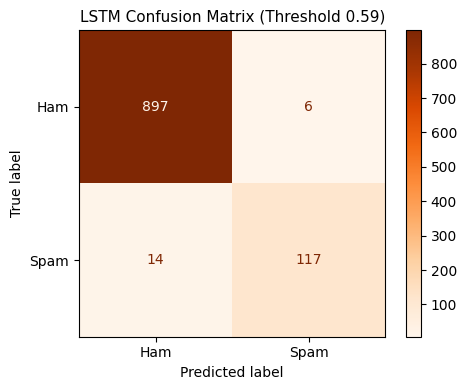

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    CV (Robustness):  147.6189 sec
    Final Training:   104.1243 sec
    Inference:        59.0388 sec
    Total Time:       310.7819 sec
    Latency (avg):    57.097477 ms/sample
    CO2 Emissions:    0.000939 kg
    Energy:           0.000328 kWh
    Gap (Train-Test): 0.0193


In [24]:
# ====================================================================================
# LSTM                      ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++  
# ====================================================================================


# Some model codes have been withheld until the paper's review process is complete. 
# Only the model results (outputs) are provided.

# All model codes will be shared once the process is finished.

### 2. GRU (Gated Recurrent Unit)


GRU MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Sequence length: 100
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)
    Max vocabulary: 10000

⏳ Starting 5-Fold Cross-Validation (Manual Loop)...
Fold   PR-AUC     Accuracy  
------------------------------
1      0.9676     0.9819
2      0.9572     0.9807
3      0.9647     0.9782
4      0.9901     0.9867
5      0.9745     0.9855
------------------------------
✓ CV completed in 142.2908 sec
✓ Average PR-AUC (CV): 0.9708 (±0.0111)

🎯 Optimizing decision threshold using aggregated CV predictions...
✓ Optimal Threshold (CV-based): 0.584
✓ Max MCC (CV): 0.9223
✓ CV Accuracy: 0.9826 ± 0.0031

TRAINING FINAL GRU MODEL

⏳ Training final GRU model with extended tracking...
Epoch 1/20
130/130 [==============================] - 9s 36ms/step - loss: 0.2325 - accuracy: 0.9253
Epoch 2/20
130/130 [==============================] - 5s 36ms/step - loss: 0.0378 - accura

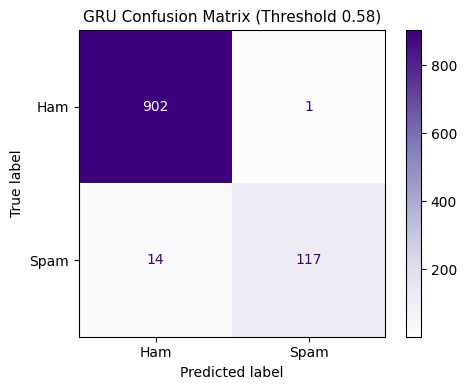

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    CV (Robustness):  142.2908 sec
    Final Training:   99.8929 sec
    Inference:        59.3279 sec
    Total Time:       301.5116 sec
    Latency (avg):    57.377085 ms/sample
    CO2 Emissions:    0.000885 kg
    Energy:           0.000310 kWh
    Gap (Train-Test): 0.0145


In [23]:
# ====================================================================================
# GRU ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# ====================================================================================

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
X_train = X_train_dl
X_test = X_test_dl
y_train = y_train_dl
y_test = y_test_dl

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Sequence length: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")
print(f"    Max vocabulary: {MAX_WORDS}")

# ================================================================================
# 5-FOLD CROSS-VALIDATION (MANUAL LOOP)
# ================================================================================
print("\n⏳ Starting 5-Fold Cross-Validation (Manual Loop)...")
timer.start("gru_cv")

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_predictions = []
cv_true_labels = []
cv_pr_scores = []
cv_accuracies = []
cv_mccs = []

print(f"{'Fold':<6} {'PR-AUC':<10} {'Accuracy':<10}")
print("-" * 30)

for fold_no, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train), 1):
    # Data split
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
    
    # Build & train model
    model_cv = create_model('gru')
    
    early_stop_cv = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=0
    )
    reduce_lr_cv = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=0
    )
    
    model_cv.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=15,
        batch_size=32,
        callbacks=[early_stop_cv, reduce_lr_cv],
        verbose=0
    )
    
    # Predict probabilities
    val_probs = model_cv.predict(X_val_fold, verbose=0).flatten()
    val_preds = (val_probs >= 0.5).astype(int)
    
    # Calculate scores
    pr_score = average_precision_score(y_val_fold, val_probs)
    acc_score = accuracy_score(y_val_fold, val_preds)
    mcc_score = matthews_corrcoef(y_val_fold, val_preds)
    
    cv_pr_scores.append(pr_score)
    cv_accuracies.append(acc_score)
    cv_mccs.append(mcc_score)
    
    # Store for threshold optimization
    cv_predictions.extend(val_probs)
    cv_true_labels.extend(y_val_fold)
    
    print(f"{fold_no:<6} {pr_score:.4f}     {acc_score:.4f}")

gru_cv_time = timer.stop("gru_cv")

print("-" * 30)
print(f"✓ CV completed in {format_time(gru_cv_time)}")
print(f"✓ Average PR-AUC (CV): {np.mean(cv_pr_scores):.4f} (±{np.std(cv_pr_scores):.4f})")

# Store CV stability metrics
threshold_metrics = {
    "cv_accuracy_mean": np.mean(cv_accuracies),
    "cv_accuracy_std": np.std(cv_accuracies),
    "cv_mcc_mean": np.mean(cv_mccs),
    "cv_mcc_std": np.std(cv_mccs),
}

# ================================================================================
# THRESHOLD OPTIMIZATION (USING AGGREGATED CV PREDICTIONS)
# ================================================================================
print("\n🎯 Optimizing decision threshold using aggregated CV predictions...")

thresholds = np.linspace(0.01, 0.99, 100)
cv_preds_arr = np.array(cv_predictions)
cv_true_arr = np.array(cv_true_labels)

mcc_scores = [
    matthews_corrcoef(cv_true_arr, (cv_preds_arr >= t).astype(int))
    for t in thresholds
]
optimal_threshold = thresholds[np.argmax(mcc_scores)]
max_mcc_cv = max(mcc_scores)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL GRU MODEL")
print("=" * 80)

# Build final model
gru_model = create_model('gru')

# Callbacks
early_stop_final = EarlyStopping(
    monitor='loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("\n⏳ Training final GRU model with extended tracking...")

# Track training with DL-specific parameters
training_metrics = track_model_training(
    model=gru_model,
    X_train=X_train,
    y_train=y_train,
    model_name="GRU",
    epochs=20,                    # DL: epochs required
    batch_size=32,                # DL: batch_size required
    callbacks=[early_stop_final], # DL: callbacks required
    verbose=1                     # Show training progress
)

gru_training_time = training_metrics["training_time"]
print(f"✓ Final model training completed in {format_time(gru_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

# Keras wrapper for inference measurement
class KerasWrapper:
    def __init__(self, model):
        self.model = model
    
    def predict_proba(self, X):
        if X.ndim == 1:
            X = X.reshape(1, -1)
        return self.model.predict(X, verbose=0)

inference_wrapper = KerasWrapper(gru_model)
inference_metrics = measure_inference_extended(
    inference_wrapper,
    X_test
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

# Predict probabilities
gru_pred_proba = gru_model.predict(X_test, verbose=0).flatten()
best_gru_predict = (gru_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict = (gru_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions for generalization gap analysis
train_pred_proba = gru_model.predict(X_train, verbose=0).flatten()
best_gru_train_predict = (train_pred_proba >= optimal_threshold).astype(int)
train_accuracy = accuracy_score(y_train, best_gru_train_predict)

# Calculate metrics
metrics = compute_metrics(
    y_test,
    best_gru_predict,
    gru_pred_proba
)

# Calculate model size
model_size_mb = 0
temp_filename = "temp_gru_model_size.h5"
try:
    gru_model.save(temp_filename, include_optimizer=False)
    model_size_mb = os.path.getsize(temp_filename) / (1024 * 1024)
    os.remove(temp_filename)
except Exception as e:
    print(f"⚠️ Could not calculate model size: {e}")

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("GRU MODEL - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:      {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference): {training_metrics['ram_inference_mb']:.2f} MB")
print(f"✓ Latency (p95):   {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):   {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ CO2 Emissions:   {training_metrics['co2_kg']:.6f} kg")
print(f"✓ Energy:          {training_metrics['energy_kwh']:.6f} kWh")

print("\n📊 Classification Report:")
print(classification_report(
    y_test,
    best_gru_predict,
    target_names=['Ham', 'Spam']
))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="GRU",
    threshold=optimal_threshold,
    cmap='Purples'
)

# ================================================================================
# RESULTS ARCHIVING (UNIFIED DICTIONARY)
# ================================================================================
total_time = gru_cv_time + gru_training_time + inference_metrics['inference_time_total']
fpr_score = 1 - metrics["Specificity"]

model_results["GRU"] = {
    # Performance metrics
    "Accuracy": metrics["Accuracy"],
    "Precision": metrics["Precision"],
    "Recall": metrics["Recall"],
    "F1_Score": metrics["F1_Score"],
    "MCC": metrics["MCC"],
    "Kappa": metrics["Kappa"],
    "ROC_AUC": metrics["ROC_AUC"],
    "PR_AUC": metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR": fpr_score,
    
    # CV stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std": threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean": threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std": threshold_metrics["cv_mcc_std"],
    
    # Optimization
    "Optimal_Threshold": optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement": metrics["Accuracy"] - default_accuracy,
    
    # Overfitting analysis
    "Train_Accuracy": train_accuracy,
    "Test_Accuracy": metrics["Accuracy"],
    "Generalization_Gap": train_accuracy - metrics["Accuracy"],
    
    # Timing
    "CV_Time": gru_cv_time,
    "Training_Time": gru_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms": inference_metrics['latency_mean_ms'],
    "Latency_p95_ms": inference_metrics['latency_p95_ms'],
    "Latency_p99_ms": inference_metrics['latency_p99_ms'],
    "Total_Time": total_time,
    
    # Energy & carbon
    "CO2_emissions_kg": training_metrics['co2_kg'],
    "Energy_kWh": training_metrics['energy_kwh'],
    "Energy_per_1000_pred_Wh": training_metrics['energy_per_1000_pred_wh'],
    "Carbon_Intensity_gCO2_kWh": training_metrics['carbon_intensity'],
    
    # Hardware
    "GPU_Used": training_metrics['gpu_used'],
    "RAM_Peak_MB": training_metrics['ram_peak_mb'],
    "RAM_Inference_MB": training_metrics['ram_inference_mb'],
    "CPU_Utilization_%": training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],
    
    # Model properties
    "Model_Size_MB": model_size_mb,
    "Parameters_Count": gru_model.count_params() if hasattr(gru_model, 'count_params') else None,
    "Category": "Deep Learning",
    "Model_Format": "h5",
    
    # Complexity
    "Training_Samples": X_train.shape[0],
    "Test_Samples": X_test.shape[0],
    "Feature_Count_or_Vocab": MAX_WORDS,
    
    # Reproducibility
    "Random_Seed": 42,
    "Dataset_Name": "SMS_Spam",
    
    # Timestamp
    "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# ================================================================================
# CSV EXPORT (FOR DATASET CREATION)
# ================================================================================
export_results_to_csv({"GRU": model_results["GRU"]}, append=True)

print("\n💾 Timing and metrics stored successfully.")
print(f"    CV (Robustness):  {format_time(gru_cv_time)}")
print(f"    Final Training:   {format_time(gru_training_time)}")
print(f"    Inference:        {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:       {format_time(total_time)}")
print(f"    Latency (avg):    {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    CO2 Emissions:    {training_metrics['co2_kg']:.6f} kg")
print(f"    Energy:           {training_metrics['energy_kwh']:.6f} kWh")
print(f"    Gap (Train-Test): {model_results['GRU']['Generalization_Gap']:.4f}")
print("=" * 80)

### 3. CNN (Convolutional Neural Network)


CNN MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Sequence length: 100
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)
    Max vocabulary: 10000

⏳ Starting 5-Fold Cross-Validation (Manual Loop)...
Fold   PR-AUC     Accuracy  
------------------------------
1      0.9674     0.9565
2      0.9641     0.9782
3      0.9573     0.9746
4      0.9725     0.9686
5      0.9727     0.9794
------------------------------
✓ CV completed in 27.6824 sec
✓ Average PR-AUC (CV): 0.9668 (±0.0057)

🎯 Optimizing decision threshold using aggregated CV predictions...
✓ Optimal Threshold (CV-based): 0.832
✓ Max MCC (CV): 0.9150
✓ CV Accuracy: 0.9715 ± 0.0084

TRAINING FINAL CNN MODEL

⏳ Training final CNN model with extended tracking...
Epoch 1/20
130/130 [==============================] - 2s 8ms/step - loss: 0.3402 - accuracy: 0.8888
Epoch 2/20
130/130 [==============================] - 1s 6ms/step - loss: 0.0670 - accuracy:

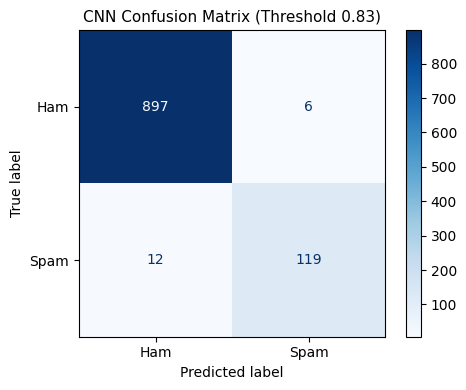

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    CV (Robustness):  27.6824 sec
    Final Training:   8.1533 sec
    Inference:        44.4404 sec
    Total Time:       80.2761 sec
    Latency (avg):    42.979142 ms/sample
    CO2 Emissions:    0.000092 kg
    Energy:           0.000032 kWh
    Gap (Train-Test): 0.0157


In [22]:
# ====================================================================================
# CNN ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# ====================================================================================


# Some model codes have been withheld until the paper's review process is complete. 
# Only the model results (outputs) are provided.

# All model codes will be shared once the process is finished.

### 4. DISTILBERT (Distilled Bidirectional Encoder Representations from Transformers)


DISTILBERT MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Loading DistilBERT tokenizer...
⏳ Encoding full dataset...
✓ Tokenization completed

⏳ Starting 5-Fold Cross-Validation (Manual Loop)...
Fold   PR-AUC     Accuracy  
------------------------------
1      0.9637     0.9855
2      0.9855     0.9867
3      0.9902     0.9891
4      0.9935     0.9940
5      0.9858     0.9879
------------------------------
✓ CV completed in 724.4889 sec
✓ Average PR-AUC (CV): 0.9837 (±0.0105)

🎯 Optimizing decision threshold using aggregated CV predictions...
✓ Optimal Threshold (CV-based): 0.911
✓ Max MCC (CV): 0.9567
✓ CV Accuracy: 0.9886 ± 0.0029

TRAINING FINAL DISTILBERT MODEL


[codecarbon WARNING @ 13:02:01] Multiple instances of codecarbon are allowed to run at the same time.



⏳ Training final DistilBERT model with extended tracking...
Epoch 1/3
259/259 [==============================] - 62s 215ms/step - loss: 0.0930 - accuracy: 0.9727
Epoch 2/3
259/259 [==============================] - 56s 216ms/step - loss: 0.0265 - accuracy: 0.9937
Epoch 3/3
259/259 [==============================] - 56s 217ms/step - loss: 0.0119 - accuracy: 0.9969
✓ Final model training completed in 174.3639 sec

⏱️ Measuring inference performance...

📊 Evaluating on test set...
⏳ Calculating train predictions for overfitting analysis...

DISTILBERT MODEL - FINAL RESULTS

✓ Accuracy (Threshold 0.91): 0.9913
✓ F1-Score: 0.9644
✓ ROC-AUC Score: 0.9993
✓ PR-AUC Score:  0.9964
✓ MCC Score:     0.9603
✓ Cohen's Kappa: 0.9595
✓ Specificity:   1.0000

✓ Model Size:      255.5393 MB
✓ RAM (Inference): 2064.54 MB
✓ Latency (p95):   66.6969 ms
✓ Latency (p99):   71.1079 ms
✓ CO2 Emissions:   0.002359 kg
✓ Energy:          0.000825 kWh

📊 Classification Report:
              precision    recall  

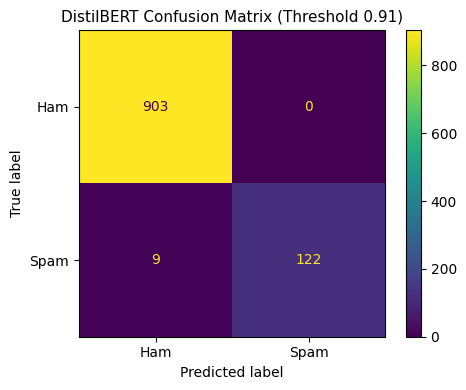

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    CV (Robustness):  724.4889 sec
    Final Training:   174.3639 sec
    Inference:        65.0340 sec
    Total Time:       963.8867 sec
    Latency (avg):    62.895515 ms/sample
    CO2 Emissions:    0.002359 kg
    Energy:           0.000825 kWh
    Gap (Train-Test): 0.0068


In [20]:
# ====================================================================================
# DISTILBERT +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# ====================================================================================

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
train_texts = df.loc[train_idx, 'text']
test_texts = df.loc[test_idx, 'text']

y_train = df.loc[train_idx, 'target'].values
y_test = df.loc[test_idx, 'target'].values

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {len(y_train)}")
print(f"    Test samples:  {len(y_test)}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")

# ================================================================================
# TOKENIZATION
# ================================================================================
print("\n Loading DistilBERT tokenizer...")
bert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def encode_texts(texts, tokenizer, max_len=128):
    """Encode texts for DistilBERT model"""
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors='tf'
    )

print(" Encoding full dataset...")
X_train_bert = encode_texts(train_texts, bert_tokenizer)
X_test_bert = encode_texts(test_texts, bert_tokenizer)
print("✓ Tokenization completed")

# ================================================================================
# 5-FOLD CROSS-VALIDATION (MANUAL LOOP)
# ================================================================================
print("\n Starting 5-Fold Cross-Validation (Manual Loop)...")
timer.start("bert_cv")

# Convert to numpy arrays for indexing
train_input_ids = X_train_bert['input_ids'].numpy()
train_attention_mask = X_train_bert['attention_mask'].numpy()

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_predictions = []
cv_true_labels = []
cv_pr_scores = []
cv_accuracies = []
cv_mccs = []

print(f"{'Fold':<6} {'PR-AUC':<10} {'Accuracy':<10}")
print("-" * 30)

for fold_no, (train_idx_fold, val_idx) in enumerate(kfold.split(train_input_ids, y_train), 1):
    # Data split
    X_train_fold_ids = train_input_ids[train_idx_fold]
    X_train_fold_mask = train_attention_mask[train_idx_fold]
    X_val_fold_ids = train_input_ids[val_idx]
    X_val_fold_mask = train_attention_mask[val_idx]
    
    y_train_fold = y_train[train_idx_fold]
    y_val_fold = y_train[val_idx]
    
    # Build & train model
    tf.keras.backend.clear_session()
    model_cv = TFDistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=2
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
    model_cv.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    
    model_cv.fit(
        {'input_ids': X_train_fold_ids, 'attention_mask': X_train_fold_mask},
        y_train_fold,
        epochs=3,
        batch_size=16,
        verbose=0
    )
    
    # Predict probabilities
    val_logits = model_cv.predict(
        {'input_ids': X_val_fold_ids, 'attention_mask': X_val_fold_mask},
        verbose=0
    ).logits
    
    val_probs = tf.nn.softmax(val_logits, axis=1).numpy()[:, 1]
    val_preds = (val_probs >= 0.5).astype(int)
    
    # Calculate scores
    pr_score = average_precision_score(y_val_fold, val_probs)
    acc_score = accuracy_score(y_val_fold, val_preds)
    mcc_score = matthews_corrcoef(y_val_fold, val_preds)
    
    cv_pr_scores.append(pr_score)
    cv_accuracies.append(acc_score)
    cv_mccs.append(mcc_score)
    
    # Store for threshold optimization
    cv_predictions.extend(val_probs)
    cv_true_labels.extend(y_val_fold)
    
    print(f"{fold_no:<6} {pr_score:.4f}     {acc_score:.4f}")

bert_cv_time = timer.stop("bert_cv")

print("-" * 30)
print(f"✓ CV completed in {format_time(bert_cv_time)}")
print(f"✓ Average PR-AUC (CV): {np.mean(cv_pr_scores):.4f} (±{np.std(cv_pr_scores):.4f})")

# Store CV stability metrics
threshold_metrics = {
    "cv_accuracy_mean": np.mean(cv_accuracies),
    "cv_accuracy_std": np.std(cv_accuracies),
    "cv_mcc_mean": np.mean(cv_mccs),
    "cv_mcc_std": np.std(cv_mccs),
}

# ================================================================================
# THRESHOLD OPTIMIZATION (USING AGGREGATED CV PREDICTIONS)
# ================================================================================
print("\n Optimizing decision threshold using aggregated CV predictions...")

thresholds = np.linspace(0.01, 0.99, 100)
cv_preds_arr = np.array(cv_predictions)
cv_true_arr = np.array(cv_true_labels)

mcc_scores = [
    matthews_corrcoef(cv_true_arr, (cv_preds_arr >= t).astype(int))
    for t in thresholds
]
optimal_threshold = thresholds[np.argmax(mcc_scores)]
max_mcc_cv = max(mcc_scores)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL DISTILBERT MODEL")
print("=" * 80)

# Build final model
tf.keras.backend.clear_session()
distilbert_model = TFDistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
distilbert_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("\n⏳ Training final DistilBERT model with extended tracking...")

# Manual tracking for DistilBERT (special handling required)
process = psutil.Process(os.getpid())
ram_baseline = process.memory_info().rss / (1024 * 1024)

# Energy tracking
if CODECARBON_AVAILABLE:
    tracker = EmissionsTracker(project_name="SMS_Spam_DistilBERT", log_level="error")
    tracker.start()

# Training
timer.start("bert_train")
history = distilbert_model.fit(
    {'input_ids': X_train_bert['input_ids'],
     'attention_mask': X_train_bert['attention_mask']},
    y_train,
    epochs=3,
    batch_size=16,
    verbose=1
)
bert_training_time = timer.stop("bert_train")

# Stop energy tracking
co2_kg = 0.0
energy_kwh = 0.0
if CODECARBON_AVAILABLE:
    try:
        emissions_data = tracker.stop()
        if emissions_data:
            co2_kg = emissions_data
            energy_kwh = emissions_data * 0.35
    except:
        pass

# RAM and hardware metrics
ram_peak = process.memory_info().rss / (1024 * 1024)
cpu_percent = psutil.cpu_percent(interval=0.1)

gpu_used = False
gpu_memory_mb = None
try:
    import GPUtil
    gpus = GPUtil.getGPUs()
    if gpus:
        gpu_used = True
        gpu_memory_mb = gpus[0].memoryUsed
except:
    pass

# Store training metrics
training_metrics = {
    "training_time": bert_training_time,
    "co2_kg": co2_kg,
    "energy_kwh": energy_kwh,
    "energy_per_1000_pred_wh": (energy_kwh * 1000 * 1000) / len(y_train) if len(y_train) > 0 else 0,
    "carbon_intensity": 350,
    "ram_baseline_mb": ram_baseline,
    "ram_peak_mb": ram_peak,
    "ram_inference_mb": ram_peak,
    "cpu_utilization": cpu_percent,
    "gpu_used": gpu_used,
    "gpu_memory_mb": gpu_memory_mb,
}

print(f"✓ Final model training completed in {format_time(bert_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES)
# ================================================================================
print("\n Measuring inference performance...")

# Warm-up
distilbert_model.predict({
    'input_ids': X_test_bert['input_ids'][:5],
    'attention_mask': X_test_bert['attention_mask'][:5]
}, verbose=0)

# Measure latency per sample
latencies = []
for i in range(len(y_test)):
    start = time.perf_counter()
    distilbert_model.predict({
        'input_ids': X_test_bert['input_ids'][i:i+1],
        'attention_mask': X_test_bert['attention_mask'][i:i+1]
    }, verbose=0)
    latencies.append((time.perf_counter() - start) * 1000)

latencies = np.array(latencies)

inference_metrics = {
    "inference_time_total": np.sum(latencies) / 1000,
    "latency_mean_ms": np.mean(latencies),
    "latency_median_ms": np.median(latencies),
    "latency_std_ms": np.std(latencies),
    "latency_min_ms": np.min(latencies),
    "latency_max_ms": np.max(latencies),
    "latency_p50_ms": np.percentile(latencies, 50),
    "latency_p95_ms": np.percentile(latencies, 95),
    "latency_p99_ms": np.percentile(latencies, 99),
}

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n Evaluating on test set...")

# Test predictions
test_logits = distilbert_model.predict({
    'input_ids': X_test_bert['input_ids'],
    'attention_mask': X_test_bert['attention_mask']
}, verbose=0).logits

bert_pred_proba = tf.nn.softmax(test_logits, axis=1).numpy()[:, 1]
best_bert_predict = (bert_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict = (bert_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions for generalization gap analysis
print("⏳ Calculating train predictions for overfitting analysis...")
train_logits = distilbert_model.predict({
    'input_ids': X_train_bert['input_ids'],
    'attention_mask': X_train_bert['attention_mask']
}, verbose=0).logits

train_proba = tf.nn.softmax(train_logits, axis=1).numpy()[:, 1]
best_bert_train_predict = (train_proba >= optimal_threshold).astype(int)
train_accuracy = accuracy_score(y_train, best_bert_train_predict)

# Calculate metrics
metrics = compute_metrics(
    y_test,
    best_bert_predict,
    bert_pred_proba
)

# Calculate model size
model_size_mb = 0
temp_dir = "distilbert_temp"
try:
    distilbert_model.save_pretrained(temp_dir)
    model_size_mb = sum(
        os.path.getsize(os.path.join(temp_dir, f))
        for f in os.listdir(temp_dir)
    ) / (1024 * 1024)
    shutil.rmtree(temp_dir)
except Exception as e:
    print(f" Could not calculate model size: {e}")

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("DISTILBERT MODEL - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:      {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference): {training_metrics['ram_inference_mb']:.2f} MB")
print(f"✓ Latency (p95):   {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):   {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ CO2 Emissions:   {training_metrics['co2_kg']:.6f} kg")
print(f"✓ Energy:          {training_metrics['energy_kwh']:.6f} kWh")

print("\n Classification Report:")
print(classification_report(
    y_test,
    best_bert_predict,
    target_names=['Ham', 'Spam']
))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="DistilBERT",
    threshold=optimal_threshold,
    cmap='viridis'
)

# ================================================================================
# RESULTS ARCHIVING (UNIFIED DICTIONARY)
# ================================================================================
total_time = bert_cv_time + bert_training_time + inference_metrics['inference_time_total']
fpr_score = 1 - metrics["Specificity"]

model_results["DistilBERT"] = {
    # Performance metrics
    "Accuracy": metrics["Accuracy"],
    "Precision": metrics["Precision"],
    "Recall": metrics["Recall"],
    "F1_Score": metrics["F1_Score"],
    "MCC": metrics["MCC"],
    "Kappa": metrics["Kappa"],
    "ROC_AUC": metrics["ROC_AUC"],
    "PR_AUC": metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR": fpr_score,
    
    # CV stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std": threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean": threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std": threshold_metrics["cv_mcc_std"],
    
    # Optimization
    "Optimal_Threshold": optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement": metrics["Accuracy"] - default_accuracy,
    
    # Overfitting analysis
    "Train_Accuracy": train_accuracy,
    "Test_Accuracy": metrics["Accuracy"],
    "Generalization_Gap": train_accuracy - metrics["Accuracy"],
    
    # Timing
    "CV_Time": bert_cv_time,
    "Training_Time": bert_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms": inference_metrics['latency_mean_ms'],
    "Latency_p95_ms": inference_metrics['latency_p95_ms'],
    "Latency_p99_ms": inference_metrics['latency_p99_ms'],
    "Total_Time": total_time,
    
    # Energy & carbon
    "CO2_emissions_kg": training_metrics['co2_kg'],
    "Energy_kWh": training_metrics['energy_kwh'],
    "Energy_per_1000_pred_Wh": training_metrics['energy_per_1000_pred_wh'],
    "Carbon_Intensity_gCO2_kWh": training_metrics['carbon_intensity'],
    
    # Hardware
    "GPU_Used": training_metrics['gpu_used'],
    "RAM_Peak_MB": training_metrics['ram_peak_mb'],
    "RAM_Inference_MB": training_metrics['ram_inference_mb'],
    "CPU_Utilization_%": training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],
    
    # Model properties
    "Model_Size_MB": model_size_mb,
    "Parameters_Count": 66955010,  # DistilBERT base parameters (fixed)
    "Category": "Deep Learning",
    "Model_Format": "tf_savedmodel",
    
    # Complexity
    "Training_Samples": len(y_train),
    "Test_Samples": len(y_test),
    "Feature_Count_or_Vocab": 30522,  # DistilBERT vocab size (fixed)
    
    # Reproducibility
    "Random_Seed": 42,
    "Dataset_Name": "SMS_Spam",
    
    # Timestamp
    "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# ================================================================================
# CSV EXPORT (FOR DATASET CREATION)
# ================================================================================
export_results_to_csv({"DistilBERT": model_results["DistilBERT"]}, append=True)

print("\n Timing and metrics stored successfully.")
print(f"    CV (Robustness):  {format_time(bert_cv_time)}")
print(f"    Final Training:   {format_time(bert_training_time)}")
print(f"    Inference:        {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:       {format_time(total_time)}")
print(f"    Latency (avg):    {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    CO2 Emissions:    {training_metrics['co2_kg']:.6f} kg")
print(f"    Energy:           {training_metrics['energy_kwh']:.6f} kWh")
print(f"    Gap (Train-Test): {model_results['DistilBERT']['Generalization_Gap']:.4f}")
print("=" * 80)

In [57]:
results_df = pd.DataFrame.from_dict(model_results, orient='index')
results_df

,Accuracy,Precision,Recall,F1_Score,MCC,Kappa,ROC_AUC,PR_AUC,Specificity,FPR,CV_Accuracy_Mean,CV_Accuracy_Std,CV_MCC_Mean,CV_MCC_Std,Optimal_Threshold,Default_Threshold_Accuracy,Threshold_Improvement,Train_Accuracy,Test_Accuracy,Generalization_Gap,CV_Time,Training_Time,Inference_Time_Sec,Latency_ms,Latency_p95_ms,Latency_p99_ms,Total_Time,CO2_emissions_kg,Energy_kWh,Energy_per_1000_pred_Wh,Carbon_Intensity_gCO2_kWh,GPU_Used,RAM_Peak_MB,RAM_Inference_MB,CPU_Utilization_%,GPU_Memory_Peak_MB,Model_Size_MB,Parameters_Count,Category,Model_Format,Training_Samples,Test_Samples,Feature_Count_or_Vocab,Random_Seed,Dataset_Name,Timestamp
DistilBERT,0.991296,1.000000,0.931298,0.964427,0.960264,0.959475,0.999315,0.996430,1.000000,0.000000,0.988634,0.002922,0.948381,0.013531,0.910808,0.993230,-0.001934,0.998065,0.991296,0.006769,724.488882,174.363878,65.033963,62.895515,66.696935,71.107858,963.886724,0.002359,0.000825,0.199636,350,False,2064.535156,2064.535156,11.5,None,255.539292,66955010.0,Deep Learning,tf_savedmodel,4135,1034,30522,42,SMS_Spam,2026-02-08 13:06:30
CNN,0.982592,0.952000,0.908397,0.929688,0.920089,0.919760,0.969973,0.948158,0.993355,0.006645,0.971463,0.008398,0.880648,0.027522,0.831616,0.981625,0.000967,0.998307,0.982592,0.015715,27.682380,8.153306,44.440433,42.979142,45.873890,48.842413,80.276120,0.000092,0.000032,0.007761,350,False,3397.882812,3397.882812,4.8,None,4.256638,1109377.0,Deep Learning,h5,4135,1034,10000,42,SMS_Spam,2026-02-08 13:09:32
GRU,0.985493,0.991525,0.893130,0.939759,0.933182,0.931538,0.990084,0.973303,0.998893,0.001107,0.982588,0.003116,0.920386,0.015329,0.584141,0.985493,0.000000,1.000000,0.985493,0.014507,142.290842,99.892890,59.327906,57.377085,63.095910,66.460082,301.511638,0.000885,0.000310,0.074948,350,False,3896.082031,3896.082031,3.5,None,4.266014,1108289.0,Deep Learning,h5,4135,1034,10000,42,SMS_Spam,2026-02-08 13:20:09
LSTM,0.980658,0.951220,0.893130,0.921260,0.910834,0.910247,0.987463,0.967280,0.993355,0.006645,0.982104,0.003368,0.918250,0.014526,0.594040,0.979691,0.000967,1.000000,0.980658,0.019342,147.618887,104.124265,59.038791,57.097477,61.553795,67.036279,310.781943,0.000939,0.000328,0.079440,350,False,3394.929688,3394.929688,1.4,None,4.396873,1142721.0,Deep Learning,h5,4135,1034,10000,42,SMS_Spam,2026-02-08 13:28:05
LightGBM,0.978723,0.916031,0.916031,0.916031,0.903849,0.903849,0.987252,0.969432,0.987818,0.012182,0.981378,0.003116,0.914022,0.014757,0.359091,0.981625,-0.002901,0.993954,0.978723,0.015231,136.024449,0.572176,128.817547,124.581767,367.192985,393.520848,265.414172,0.000008,0.000003,0.000665,350,False,3545.992188,3545.992188,4.2,None,1.110813,3100.0,Ensemble,pkl,4135,1034,57376,42,SMS_Spam,2026-02-08 13:33:48
XGBoost,0.980658,0.930233,0.916031,0.923077,0.912051,0.912016,0.984881,0.967137,0.990033,0.009967,0.981378,0.003116,0.913690,0.014937,0.340909,0.978723,0.001934,0.991778,0.980658,0.011120,65.620207,1.423104,0.752244,0.727509,0.884610,1.116001,67.795555,0.000012,0.000004,0.001032,350,False,3540.324219,3540.324219,0.0,None,0.132394,NaN,Ensemble,pkl,4135,1034,57376,42,SMS_Spam,2026-02-08 13:37:34
RandomForest,0.977756,0.928571,0.893130,0.910506,0.898033,0.897811,0.988723,0.966291,0.990033,0.009967,0.922854,0.004861,0.597305,0.029311,0.186364,0.926499,0.051257,0.982588,0.977756,0.004831,51.210343,0.628054,23.181074,22.418834,23.654370,26.418681,75.019472,0.000007,0.000002,0.000579,350,False,3540.917969,3540.917969,0.0,None,0.872018,10412.0,Ensemble,pkl,4135,1034,57376,42,SMS_Spam,2026-02-08 13:40:01
SVM,0.980658,0.911111,0.938931,0.924812,0.913852,0.913716,0.993461,0.969790,0.986711,0.013289,0.976300,0.003298,0.888971,0.016414,0.177273,0.983559,-0.002901,1.000000,0.980658,0.019342,29.432946,2.338468,0.521943,0.504781,0.696570,0.857405,32.293357,0.000020,0.000007,0.001695,350,False,2319.273438,2319.273438,0.0,None,0.343959,859.0,Classical,pkl,4135,1034,57376,42,SMS_Spam,2026-02-08 13:45:53
NaiveBayes,0.983559,0.945312,0.923664,0.934363,0.925048,0.924967,0.984086,0.967977,0.9

In [34]:
# =============================================================================
# STORE DATASET STATISTICS FOR REPORT
# =============================================================================

# Extract target values from the global dataframe
y_array = df['target'].values

# Determine Vocabulary Size
# Priority: Deep Learning Tokenizer > CountVectorizer > Default 0
if 'tokenizer' in globals():
    vocab_size = len(tokenizer.word_index)
elif 'cv' in globals():
    vocab_size = len(cv.vocabulary_)
else:
    vocab_size = 0

dataset_stats = {
    'total_messages': len(df),
    
    # Class Distribution (Ham=0, Spam=1)
    'ham_count': int((y_array == 0).sum()),
    'spam_count': int((y_array == 1).sum()),
    
    'ham_percentage': float((y_array == 0).sum() / len(y_array) * 100),
    'spam_percentage': float((y_array == 1).sum() / len(y_array) * 100),
    
    # Split Sizes (Based on Global Indices)
    'train_size': len(train_idx),
    'test_size': len(test_idx),
    
    # Text Features
    'vocabulary_size': vocab_size,
    'max_sequence_length': MAX_LEN,
    
    # Feature Dimension (For Classical ML)
    'feature_dim': X_train_cv.shape[1] if 'X_train_cv' in globals() else 0,
    
    # Model Counts Breakdown
    'total_models': 10,      # Total count of trained models
    'classical_models': 3,   # LR, SVM, NB
    'ensemble_models': 3,    # RF, CatBoost, XGBoost
    'deep_learning_models': 4 # LSTM, GRU, CNN, DistilBERT
}

# =============================================================================
# PRINT STATISTICS
# =============================================================================
print("=" * 80)
print(" Dataset Statistics Saved Successfully ")
print("=" * 80)
print(f"  • Total Messages:     {dataset_stats['total_messages']}")
print(f"  • Ham Messages:       {dataset_stats['ham_count']} ({dataset_stats['ham_percentage']:.2f}%)")
print(f"  • Spam Messages:      {dataset_stats['spam_count']} ({dataset_stats['spam_percentage']:.2f}%)")
print("-" * 80)
print(f"  • Train Set Size:     {dataset_stats['train_size']}")
print(f"  • Test Set Size:      {dataset_stats['test_size']}")
print(f"  • Vocabulary Size:    {dataset_stats['vocabulary_size']}")
print(f"  • Max Sequence Len:   {dataset_stats['max_sequence_length']}")
print("-" * 80)
print(f"  • Total Models:       {dataset_stats['total_models']}")
print(f"    - Classical:        {dataset_stats['classical_models']}")
print(f"    - Ensemble:         {dataset_stats['ensemble_models']}")
print(f"    - Deep Learning:    {dataset_stats['deep_learning_models']}")
print("=" * 80 + "\n")

 Dataset Statistics Saved Successfully 
  • Total Messages:     5169
  • Ham Messages:       4516 (87.37%)
  • Spam Messages:      653 (12.63%)
--------------------------------------------------------------------------------
  • Train Set Size:     4135
  • Test Set Size:      1034
  • Vocabulary Size:    7816
  • Max Sequence Len:   100
--------------------------------------------------------------------------------
  • Total Models:       10
    - Classical:        3
    - Ensemble:         3
    - Deep Learning:    4



## Comparison Models

### 1. Performance Metrics Table

In [35]:
# ====================================================================================
# HÜCRE 1: PERFORMANCE METRICS TABLE
# ====================================================================================

print("\n" + "=" * 120)
print("PERFORMANCE METRICS LEADERBOARD (Sorted by MCC)")
print("=" * 120)

# Prepare data
performance_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model": model_name,
        "Category": metrics.get("Category", "Unknown"),
        "Accuracy": metrics.get("Accuracy", 0),
        "Precision": metrics.get("Precision", 0),
        "Recall": metrics.get("Recall", 0),
        "F1-Score": metrics.get("F1_Score", 0),
        "MCC": metrics.get("MCC", 0),
        "Kappa": metrics.get("Kappa", 0),
        "ROC-AUC": metrics.get("ROC_AUC", 0),
        "PR-AUC": metrics.get("PR_AUC", 0),
        "Specificity": metrics.get("Specificity", 0),
        "FPR": metrics.get("FPR", 0)
    }
    performance_data.append(row)

# Create DataFrame
df_performance = pd.DataFrame(performance_data)

# Sort by MCC (primary), F1-Score (secondary), Precision (tertiary)
df_performance = df_performance.sort_values(
    by=["MCC", "F1-Score", "Precision"],
    ascending=[False, False, False]
).reset_index(drop=True)

# Add rank
df_performance.insert(0, "Rank", range(1, len(df_performance) + 1))

# Display table
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_performance.to_string(index=False, float_format="%.4f"))
print("=" * 120)

# Category-wise summary
print("\n📊 CATEGORY-WISE AVERAGE PERFORMANCE:")
print("-" * 100)
summary_perf = df_performance.groupby("Category")[
    ["Accuracy", "Precision", "Recall", "F1-Score", "MCC", "ROC-AUC"]
].mean().sort_values(by="MCC", ascending=False)
print(summary_perf.to_string(float_format="%.4f"))
print("-" * 100)

# Champion model
champion = df_performance.iloc[0]
print("\n" + "=" * 120)
print(f"🏆 CHAMPION MODEL: {champion['Model'].upper()}")
print("-" * 120)
print(f"   Category:      {champion['Category']}")
print(f"   MCC:           {champion['MCC']:.4f}")
print(f"   F1-Score:      {champion['F1-Score']:.4f}")
print(f"   Accuracy:      {champion['Accuracy']:.4f}")
print(f"   ROC-AUC:       {champion['ROC-AUC']:.4f}")
print("=" * 120)


PERFORMANCE METRICS LEADERBOARD (Sorted by MCC)
 Rank        Model      Category  Accuracy  Precision  Recall  F1-Score    MCC  Kappa  ROC-AUC  PR-AUC  Specificity    FPR
    1   DistilBERT Deep Learning    0.9913     1.0000  0.9313    0.9644 0.9603 0.9595   0.9993  0.9964       1.0000 0.0000
    2          GRU Deep Learning    0.9855     0.9915  0.8931    0.9398 0.9332 0.9315   0.9901  0.9733       0.9989 0.0011
    3   NaiveBayes     Classical    0.9836     0.9453  0.9237    0.9344 0.9250 0.9250   0.9841  0.9680       0.9922 0.0078
    4           LR     Classical    0.9826     0.9248  0.9389    0.9318 0.9219 0.9218   0.9911  0.9666       0.9889 0.0111
    5          CNN Deep Learning    0.9826     0.9520  0.9084    0.9297 0.9201 0.9198   0.9700  0.9482       0.9934 0.0066
    6          SVM     Classical    0.9807     0.9111  0.9389    0.9248 0.9139 0.9137   0.9935  0.9698       0.9867 0.0133
    7      XGBoost      Ensemble    0.9807     0.9302  0.9160    0.9231 0.9121 0.9120   0.

### 2. Efficiency & Mobile Metrics Table

In [36]:
# ====================================================================================
# HÜCRE 2: EFFICIENCY & MOBILE METRICS TABLE
# ====================================================================================

print("\n" + "=" * 120)
print("EFFICIENCY & MOBILE DEPLOYMENT METRICS (Sorted by Latency p95)")
print("=" * 120)

# Prepare data
efficiency_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model": model_name,
        "Category": metrics.get("Category", "Unknown"),
        "Model Size (MB)": metrics.get("Model_Size_MB", 0),
        "RAM Inference (MB)": metrics.get("RAM_Inference_MB", 0),
        "Latency Mean (ms)": metrics.get("Latency_ms", 0),
        "Latency p95 (ms)": metrics.get("Latency_p95_ms", 0),
        "Latency p99 (ms)": metrics.get("Latency_p99_ms", 0),
        "Training Time (s)": metrics.get("Training_Time", 0),
        "Inference Time (s)": metrics.get("Inference_Time_Sec", 0)
    }
    efficiency_data.append(row)

# Create DataFrame
df_efficiency = pd.DataFrame(efficiency_data)

# Sort by Latency p95 (ascending - lower is better)
df_efficiency = df_efficiency.sort_values(
    by=["Latency p95 (ms)", "Model Size (MB)"],
    ascending=[True, True]
).reset_index(drop=True)

# Add rank
df_efficiency.insert(0, "Rank", range(1, len(df_efficiency) + 1))

# Display table
print(df_efficiency.to_string(index=False, float_format="%.4f"))
print("=" * 120)

# Category-wise summary
print("\n📱 CATEGORY-WISE EFFICIENCY SUMMARY:")
print("-" * 100)
summary_eff = df_efficiency.groupby("Category")[
    ["Model Size (MB)", "RAM Inference (MB)", "Latency Mean (ms)", "Latency p95 (ms)"]
].mean().sort_values(by="Latency p95 (ms)", ascending=True)
print(summary_eff.to_string(float_format="%.4f"))
print("-" * 100)

# Most efficient model
most_efficient = df_efficiency.iloc[0]
print("\n" + "=" * 120)
print(f"⚡ MOST EFFICIENT MODEL (Mobile): {most_efficient['Model'].upper()}")
print("-" * 120)
print(f"   Category:          {most_efficient['Category']}")
print(f"   Latency p95:       {most_efficient['Latency p95 (ms)']:.4f} ms")
print(f"   Model Size:        {most_efficient['Model Size (MB)']:.4f} MB")
print(f"   RAM (Inference):   {most_efficient['RAM Inference (MB)']:.2f} MB")
print("=" * 120)


EFFICIENCY & MOBILE DEPLOYMENT METRICS (Sorted by Latency p95)
 Rank        Model      Category  Model Size (MB)  RAM Inference (MB)  Latency Mean (ms)  Latency p95 (ms)  Latency p99 (ms)  Training Time (s)  Inference Time (s)
    1           LR     Classical           0.4386           2323.0156             0.1988            0.2498            0.3115             0.0753              0.2055
    2          SVM     Classical           0.3440           2319.2734             0.5048            0.6966            0.8574             2.3385              0.5219
    3   NaiveBayes     Classical           1.7517           2319.4102             0.6607            0.7754            0.9334             0.0031              0.6831
    4      XGBoost      Ensemble           0.1324           3540.3242             0.7275            0.8846            1.1160             1.4231              0.7522
    5 RandomForest      Ensemble           0.8720           3540.9180            22.4188           23.6544          

### 3. Sustainability Metrics Table

In [37]:
# ====================================================================================
# HÜCRE 3: SUSTAINABILITY METRICS TABLE
# ====================================================================================

print("\n" + "=" * 120)
print("SUSTAINABILITY & ENERGY METRICS (Sorted by CO2 Emissions)")
print("=" * 120)

# Prepare data
sustainability_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model": model_name,
        "Category": metrics.get("Category", "Unknown"),
        "CO2 Emissions (kg)": metrics.get("CO2_emissions_kg", 0),
        "Energy (kWh)": metrics.get("Energy_kWh", 0),
        "Energy/1000 pred (Wh)": metrics.get("Energy_per_1000_pred_Wh", 0),
        "Training Time (s)": metrics.get("Training_Time", 0),
        "CV Time (s)": metrics.get("CV_Time", 0),
        "Total Time (s)": metrics.get("Total_Time", 0),
        "GPU Used": "Yes" if metrics.get("GPU_Used", False) else "No"
    }
    sustainability_data.append(row)

# Create DataFrame
df_sustainability = pd.DataFrame(sustainability_data)

# Sort by CO2 emissions (ascending - lower is better)
df_sustainability = df_sustainability.sort_values(
    by=["CO2 Emissions (kg)", "Energy (kWh)"],
    ascending=[True, True]
).reset_index(drop=True)

# Add rank
df_sustainability.insert(0, "Rank", range(1, len(df_sustainability) + 1))

# Display table
print(df_sustainability.to_string(index=False, float_format="%.6f"))
print("=" * 120)

# Category-wise summary
print("\n🌍 CATEGORY-WISE SUSTAINABILITY SUMMARY:")
print("-" * 100)
summary_sust = df_sustainability.groupby("Category")[
    ["CO2 Emissions (kg)", "Energy (kWh)", "Energy/1000 pred (Wh)", "Total Time (s)"]
].mean().sort_values(by="CO2 Emissions (kg)", ascending=True)
print(summary_sust.to_string(float_format="%.6f"))
print("-" * 100)

# Most sustainable model
most_sustainable = df_sustainability.iloc[0]
print("\n" + "=" * 120)
print(f"🌱 MOST SUSTAINABLE MODEL: {most_sustainable['Model'].upper()}")
print("-" * 120)
print(f"   Category:              {most_sustainable['Category']}")
print(f"   CO2 Emissions:         {most_sustainable['CO2 Emissions (kg)']:.6f} kg")
print(f"   Energy Consumption:    {most_sustainable['Energy (kWh)']:.6f} kWh")
print(f"   Total Time:            {most_sustainable['Total Time (s)']:.2f} s")
print("=" * 120)


SUSTAINABILITY & ENERGY METRICS (Sorted by CO2 Emissions)
 Rank        Model      Category  CO2 Emissions (kg)  Energy (kWh)  Energy/1000 pred (Wh)  Training Time (s)  CV Time (s)  Total Time (s) GPU Used
    1   NaiveBayes     Classical            0.000003      0.000001               0.000295           0.003118     0.206203        0.892444       No
    2           LR     Classical            0.000004      0.000001               0.000314           0.075259     1.389529        1.670337       No
    3 RandomForest      Ensemble            0.000007      0.000002               0.000579           0.628054    51.210343       75.019472       No
    4     LightGBM      Ensemble            0.000008      0.000003               0.000665           0.572176   136.024449      265.414172       No
    5      XGBoost      Ensemble            0.000012      0.000004               0.001032           1.423104    65.620207       67.795555       No
    6          SVM     Classical            0.000020      0

### 4. Statistical Rigor & Stability Table

In [38]:
# ====================================================================================
# HÜCRE 4: STATISTICAL RIGOR & STABILITY TABLE
# ====================================================================================

print("\n" + "=" * 120)
print("STATISTICAL RIGOR & STABILITY METRICS (Sorted by Generalization Gap)")
print("=" * 120)

# Prepare data
stability_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model": model_name,
        "Category": metrics.get("Category", "Unknown"),
        "CV Acc Mean": metrics.get("CV_Accuracy_Mean", 0),
        "CV Acc Std": metrics.get("CV_Accuracy_Std", 0),
        "CV MCC Mean": metrics.get("CV_MCC_Mean", 0),
        "CV MCC Std": metrics.get("CV_MCC_Std", 0),
        "Train Accuracy": metrics.get("Train_Accuracy", 0),
        "Test Accuracy": metrics.get("Test_Accuracy", 0),
        "Gen. Gap": metrics.get("Generalization_Gap", 0),
        "Optimal Threshold": metrics.get("Optimal_Threshold", 0),
        "Threshold Improvement": metrics.get("Threshold_Improvement", 0)
    }
    stability_data.append(row)

# Create DataFrame
df_stability = pd.DataFrame(stability_data)

# Sort by Generalization Gap (ascending - lower is better)
df_stability = df_stability.sort_values(
    by=["Gen. Gap", "CV Acc Std"],
    ascending=[True, True]
).reset_index(drop=True)

# Add rank
df_stability.insert(0, "Rank", range(1, len(df_stability) + 1))

# Display table
print(df_stability.to_string(index=False, float_format="%.4f"))
print("=" * 120)

# Category-wise summary
print("\n📊 CATEGORY-WISE STABILITY SUMMARY:")
print("-" * 100)
summary_stab = df_stability.groupby("Category")[
    ["CV Acc Mean", "CV Acc Std", "CV MCC Mean", "CV MCC Std", "Gen. Gap"]
].mean().sort_values(by="Gen. Gap", ascending=True)
print(summary_stab.to_string(float_format="%.4f"))
print("-" * 100)

# Most stable model
most_stable = df_stability.iloc[0]
print("\n" + "=" * 120)
print(f"🎯 MOST STABLE MODEL (Best Generalization): {most_stable['Model'].upper()}")
print("-" * 120)
print(f"   Category:              {most_stable['Category']}")
print(f"   Generalization Gap:    {most_stable['Gen. Gap']:.4f}")
print(f"   CV Accuracy:           {most_stable['CV Acc Mean']:.4f} ± {most_stable['CV Acc Std']:.4f}")
print(f"   CV MCC:                {most_stable['CV MCC Mean']:.4f} ± {most_stable['CV MCC Std']:.4f}")
print("=" * 120)


STATISTICAL RIGOR & STABILITY METRICS (Sorted by Generalization Gap)
 Rank        Model      Category  CV Acc Mean  CV Acc Std  CV MCC Mean  CV MCC Std  Train Accuracy  Test Accuracy  Gen. Gap  Optimal Threshold  Threshold Improvement
    1 RandomForest      Ensemble       0.9229      0.0049       0.5973      0.0293          0.9826         0.9778    0.0048             0.1864                 0.0513
    2   DistilBERT Deep Learning       0.9886      0.0029       0.9484      0.0135          0.9981         0.9913    0.0068             0.9108                -0.0019
    3      XGBoost      Ensemble       0.9814      0.0031       0.9137      0.0149          0.9918         0.9807    0.0111             0.3409                 0.0019
    4          GRU Deep Learning       0.9826      0.0031       0.9204      0.0153          1.0000         0.9855    0.0145             0.5841                 0.0000
    5     LightGBM      Ensemble       0.9814      0.0031       0.9140      0.0148          0.9940  

### 5. Performance Visualization


GENERATING PERFORMANCE VISUALIZATIONS...


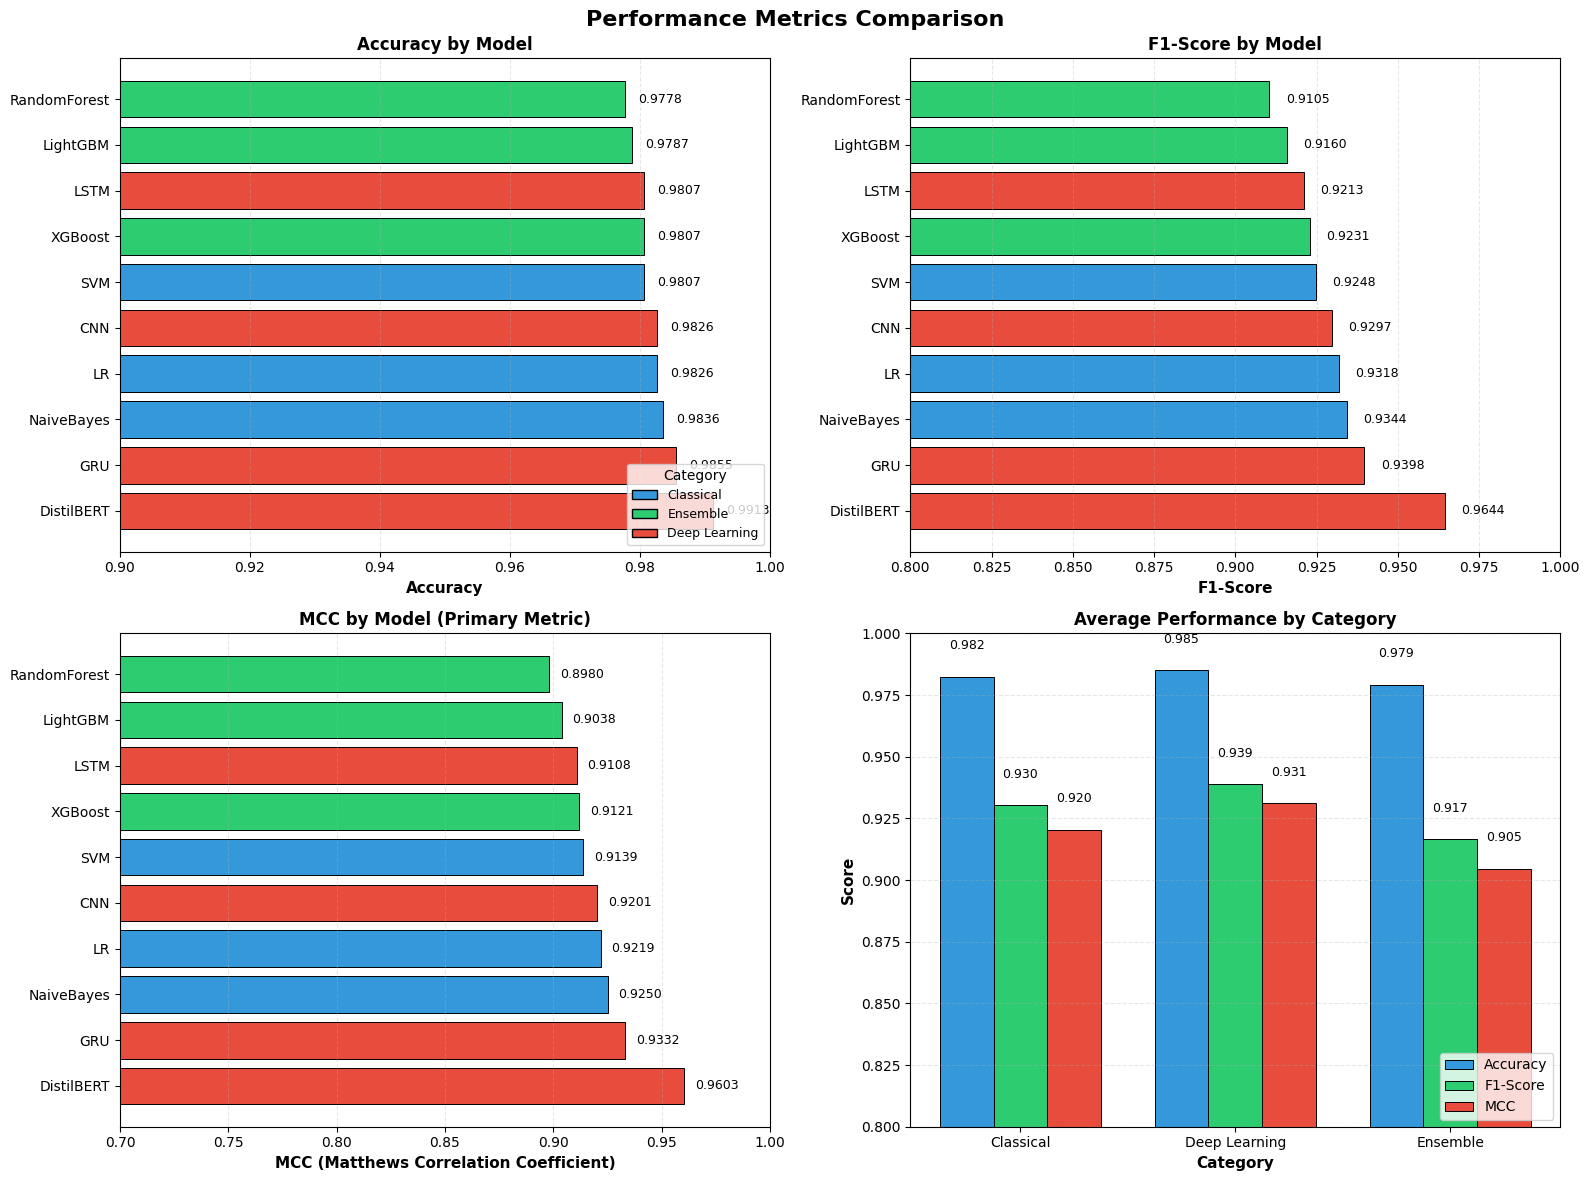

✓ Performance visualizations generated successfully!


In [39]:
# ====================================================================================
# HÜCRE 5: PERFORMANCE VISUALIZATION
# ====================================================================================

import matplotlib.pyplot as plt
import numpy as np

print("\n" + "=" * 80)
print("GENERATING PERFORMANCE VISUALIZATIONS...")
print("=" * 80)

# Prepare data from model_results
models = []
categories = []
accuracy = []
f1_scores = []
mcc_scores = []

for model_name, metrics in model_results.items():
    models.append(model_name)
    categories.append(metrics.get("Category", "Unknown"))
    accuracy.append(metrics.get("Accuracy", 0))
    f1_scores.append(metrics.get("F1_Score", 0))
    mcc_scores.append(metrics.get("MCC", 0))

# Create DataFrame for easier plotting
df_viz = pd.DataFrame({
    'Model': models,
    'Category': categories,
    'Accuracy': accuracy,
    'F1-Score': f1_scores,
    'MCC': mcc_scores
})

# Sort by MCC
df_viz = df_viz.sort_values('MCC', ascending=False)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Performance Metrics Comparison', fontsize=16, fontweight='bold')

# Color mapping for categories
category_colors = {
    'Classical': '#3498db',
    'Ensemble': '#2ecc71',
    'Deep Learning': '#e74c3c'
}
colors = [category_colors.get(cat, '#95a5a6') for cat in df_viz['Category']]

# Plot 1: Accuracy comparison
ax1 = axes[0, 0]
bars1 = ax1.barh(df_viz['Model'], df_viz['Accuracy'], color=colors, edgecolor='black', linewidth=0.7)
ax1.set_xlabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Accuracy by Model', fontsize=12, fontweight='bold')
ax1.set_xlim([0.9, 1.0])
ax1.grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(df_viz['Accuracy']):
    ax1.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

# Plot 2: F1-Score comparison
ax2 = axes[0, 1]
bars2 = ax2.barh(df_viz['Model'], df_viz['F1-Score'], color=colors, edgecolor='black', linewidth=0.7)
ax2.set_xlabel('F1-Score', fontsize=11, fontweight='bold')
ax2.set_title('F1-Score by Model', fontsize=12, fontweight='bold')
ax2.set_xlim([0.8, 1.0])
ax2.grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(df_viz['F1-Score']):
    ax2.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# Plot 3: MCC comparison
ax3 = axes[1, 0]
bars3 = ax3.barh(df_viz['Model'], df_viz['MCC'], color=colors, edgecolor='black', linewidth=0.7)
ax3.set_xlabel('MCC (Matthews Correlation Coefficient)', fontsize=11, fontweight='bold')
ax3.set_title('MCC by Model (Primary Metric)', fontsize=12, fontweight='bold')
ax3.set_xlim([0.7, 1.0])
ax3.grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(df_viz['MCC']):
    ax3.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# Plot 4: Category-wise grouped comparison
ax4 = axes[1, 1]
category_summary = df_viz.groupby('Category')[['Accuracy', 'F1-Score', 'MCC']].mean()
x_pos = np.arange(len(category_summary))
width = 0.25

bars_acc = ax4.bar(x_pos - width, category_summary['Accuracy'], width, 
                   label='Accuracy', color='#3498db', edgecolor='black', linewidth=0.7)
bars_f1 = ax4.bar(x_pos, category_summary['F1-Score'], width, 
                  label='F1-Score', color='#2ecc71', edgecolor='black', linewidth=0.7)
bars_mcc = ax4.bar(x_pos + width, category_summary['MCC'], width, 
                   label='MCC', color='#e74c3c', edgecolor='black', linewidth=0.7)

ax4.set_xlabel('Category', fontsize=11, fontweight='bold')
ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('Average Performance by Category', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(category_summary.index, fontsize=10)
ax4.legend(loc='lower right', fontsize=10)
ax4.set_ylim([0.8, 1.0])
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [bars_acc, bars_f1, bars_mcc]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Legend for categories (add to first plot)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor='black', label=cat) 
                   for cat, color in category_colors.items()]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9, title='Category')

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Performance visualizations generated successfully!")

### 6. Efficiency Trade-offs


GENERATING EFFICIENCY TRADE-OFF VISUALIZATIONS...


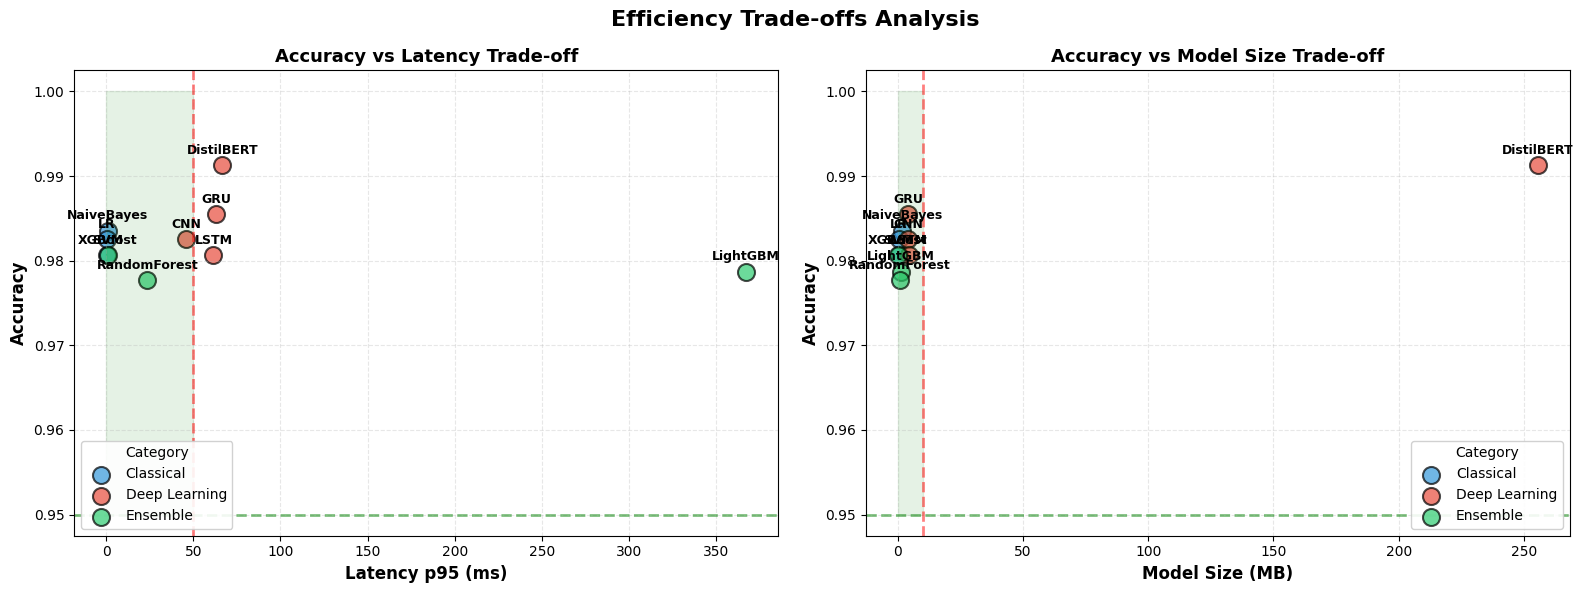

✓ Efficiency trade-off visualizations generated successfully!


In [40]:
# ====================================================================================
# HÜCRE 6: EFFICIENCY TRADE-OFFS
# ====================================================================================

print("\n" + "=" * 80)
print("GENERATING EFFICIENCY TRADE-OFF VISUALIZATIONS...")
print("=" * 80)

# Prepare data
models = []
categories = []
accuracy = []
latency_p95 = []
model_size = []

for model_name, metrics in model_results.items():
    models.append(model_name)
    categories.append(metrics.get("Category", "Unknown"))
    accuracy.append(metrics.get("Accuracy", 0))
    latency_p95.append(metrics.get("Latency_p95_ms", 0))
    model_size.append(metrics.get("Model_Size_MB", 0))

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Efficiency Trade-offs Analysis', fontsize=16, fontweight='bold')

# Color mapping
category_colors = {
    'Classical': '#3498db',
    'Ensemble': '#2ecc71',
    'Deep Learning': '#e74c3c'
}

# Plot 1: Accuracy vs Latency (p95)
ax1 = axes[0]
for category in set(categories):
    mask = [c == category for c in categories]
    acc_cat = [a for a, m in zip(accuracy, mask) if m]
    lat_cat = [l for l, m in zip(latency_p95, mask) if m]
    mod_cat = [m for m, ma in zip(models, mask) if ma]
    
    ax1.scatter(lat_cat, acc_cat, s=150, alpha=0.7, 
                color=category_colors.get(category, '#95a5a6'),
                edgecolors='black', linewidth=1.5, label=category)
    
    # Add labels
    for i, model in enumerate(mod_cat):
        ax1.annotate(model, (lat_cat[i], acc_cat[i]), 
                    textcoords="offset points", xytext=(0,8), 
                    ha='center', fontsize=9, fontweight='bold')

ax1.set_xlabel('Latency p95 (ms)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy vs Latency Trade-off', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='lower left', fontsize=10, title='Category', framealpha=0.9)

# Mobile suitability zone (Latency < 50ms, Accuracy > 0.95)
ax1.axvline(x=50, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Mobile threshold (50ms)')
ax1.axhline(y=0.95, color='green', linestyle='--', linewidth=2, alpha=0.5, label='High accuracy (95%)')
ax1.fill_between([0, 50], 0.95, 1.0, alpha=0.1, color='green', label='Mobile suitability zone')

# Plot 2: Accuracy vs Model Size
ax2 = axes[1]
for category in set(categories):
    mask = [c == category for c in categories]
    acc_cat = [a for a, m in zip(accuracy, mask) if m]
    size_cat = [s for s, m in zip(model_size, mask) if m]
    mod_cat = [m for m, ma in zip(models, mask) if ma]
    
    ax2.scatter(size_cat, acc_cat, s=150, alpha=0.7,
                color=category_colors.get(category, '#95a5a6'),
                edgecolors='black', linewidth=1.5, label=category)
    
    # Add labels
    for i, model in enumerate(mod_cat):
        ax2.annotate(model, (size_cat[i], acc_cat[i]),
                    textcoords="offset points", xytext=(0,8),
                    ha='center', fontsize=9, fontweight='bold')

ax2.set_xlabel('Model Size (MB)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Accuracy vs Model Size Trade-off', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(loc='lower right', fontsize=10, title='Category', framealpha=0.9)

# Mobile suitability zone (Size < 10MB, Accuracy > 0.95)
ax2.axvline(x=10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Mobile threshold (10MB)')
ax2.axhline(y=0.95, color='green', linestyle='--', linewidth=2, alpha=0.5, label='High accuracy (95%)')
ax2.fill_between([0, 10], 0.95, 1.0, alpha=0.1, color='green', label='Mobile suitability zone')

plt.tight_layout()
plt.savefig('efficiency_tradeoffs.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Efficiency trade-off visualizations generated successfully!")

### 7. Sustainability Analysis


GENERATING SUSTAINABILITY VISUALIZATIONS...


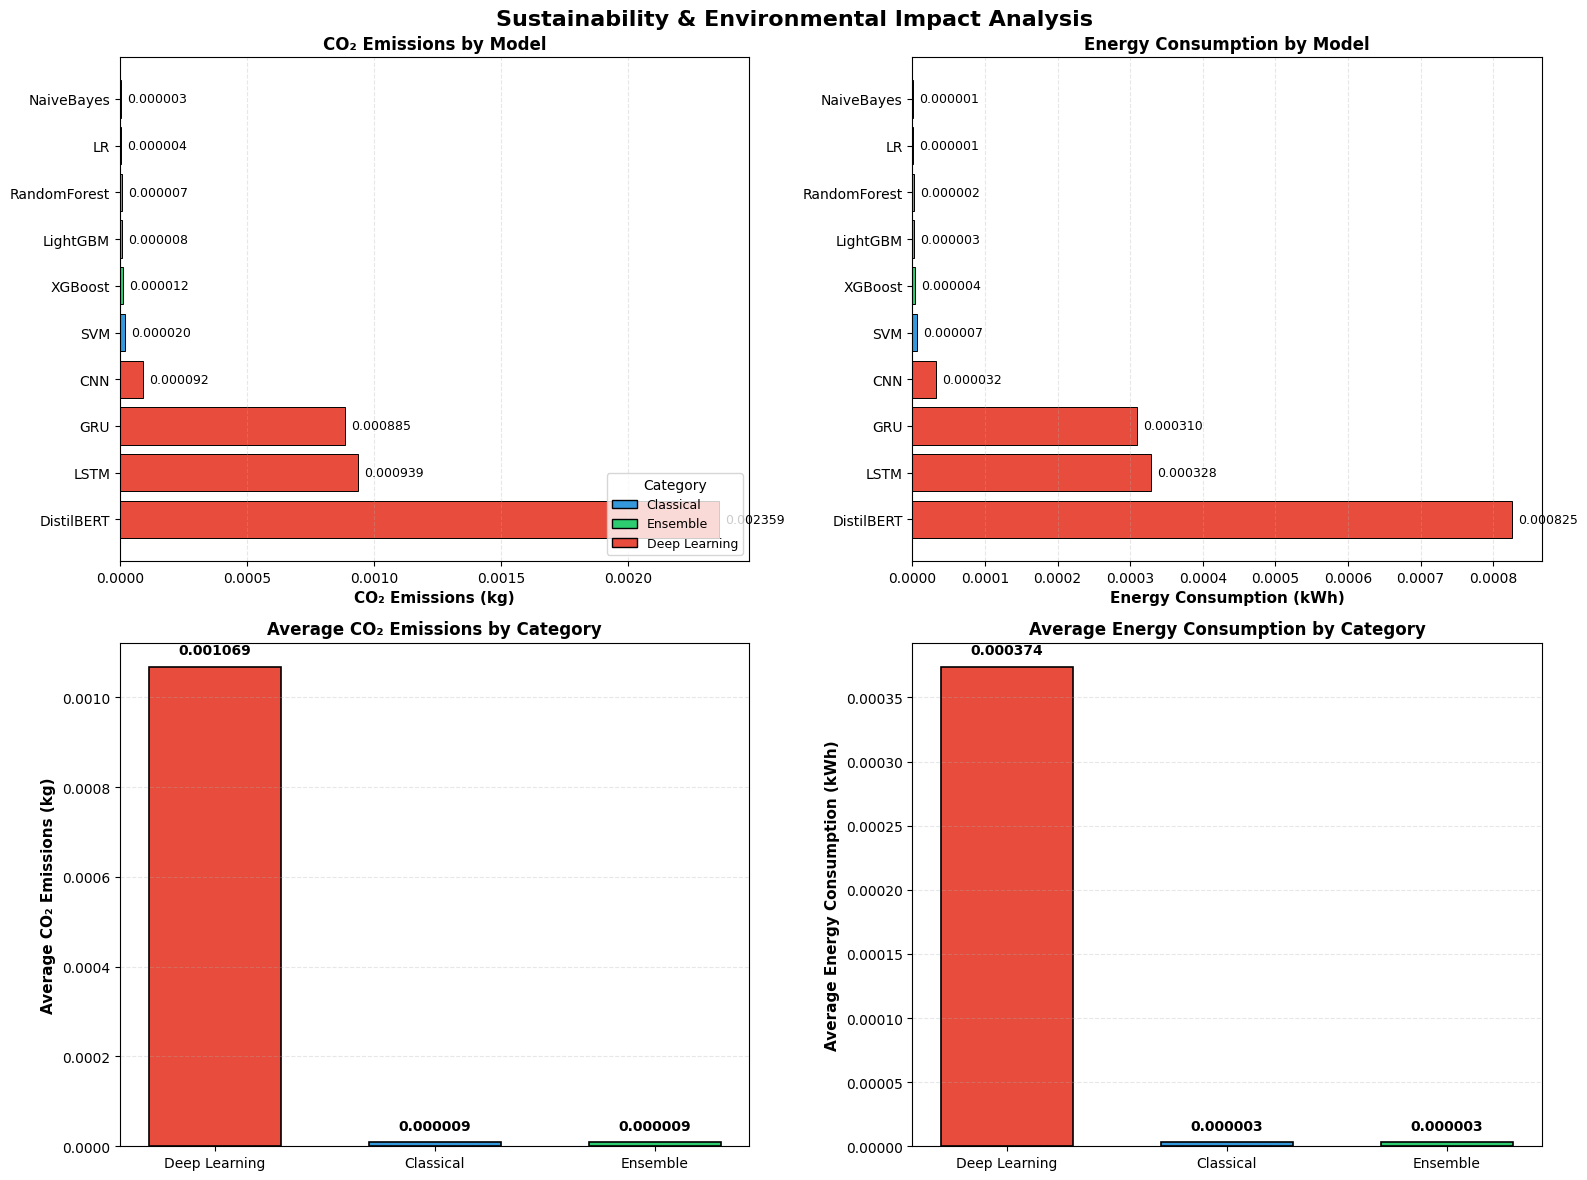

✓ Sustainability visualizations generated successfully!

📊 Summary:
   Most sustainable model: NaiveBayes (0.000003 kg CO₂)
   Least sustainable model: DistilBERT (0.002359 kg CO₂)
   Average CO₂ emissions: 0.000433 kg


In [41]:
# ====================================================================================
# HÜCRE 7: SUSTAINABILITY ANALYSIS
# ====================================================================================

print("\n" + "=" * 80)
print("GENERATING SUSTAINABILITY VISUALIZATIONS...")
print("=" * 80)

# Prepare data
models = []
categories = []
co2_emissions = []
energy_kwh = []

for model_name, metrics in model_results.items():
    models.append(model_name)
    categories.append(metrics.get("Category", "Unknown"))
    co2_emissions.append(metrics.get("CO2_emissions_kg", 0))
    energy_kwh.append(metrics.get("Energy_kWh", 0))

# Create DataFrame
df_sust = pd.DataFrame({
    'Model': models,
    'Category': categories,
    'CO2 (kg)': co2_emissions,
    'Energy (kWh)': energy_kwh
})

# Sort by CO2
df_sust = df_sust.sort_values('CO2 (kg)', ascending=False)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sustainability & Environmental Impact Analysis', fontsize=16, fontweight='bold')

# Color mapping
category_colors = {
    'Classical': '#3498db',
    'Ensemble': '#2ecc71',
    'Deep Learning': '#e74c3c'
}
colors = [category_colors.get(cat, '#95a5a6') for cat in df_sust['Category']]

# Plot 1: CO2 emissions by model
ax1 = axes[0, 0]
bars1 = ax1.barh(df_sust['Model'], df_sust['CO2 (kg)'], color=colors, 
                 edgecolor='black', linewidth=0.7)
ax1.set_xlabel('CO₂ Emissions (kg)', fontsize=11, fontweight='bold')
ax1.set_title('CO₂ Emissions by Model', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(df_sust['CO2 (kg)']):
    ax1.text(v + max(df_sust['CO2 (kg)'])*0.01, i, f'{v:.6f}', 
            va='center', fontsize=9)

# Plot 2: Energy consumption by model
ax2 = axes[0, 1]
bars2 = ax2.barh(df_sust['Model'], df_sust['Energy (kWh)'], color=colors,
                 edgecolor='black', linewidth=0.7)
ax2.set_xlabel('Energy Consumption (kWh)', fontsize=11, fontweight='bold')
ax2.set_title('Energy Consumption by Model', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(df_sust['Energy (kWh)']):
    ax2.text(v + max(df_sust['Energy (kWh)'])*0.01, i, f'{v:.6f}', 
            va='center', fontsize=9)

# Plot 3: Category-wise CO2 comparison
ax3 = axes[1, 0]
category_co2 = df_sust.groupby('Category')['CO2 (kg)'].mean().sort_values(ascending=False)
colors_cat = [category_colors.get(cat, '#95a5a6') for cat in category_co2.index]
bars3 = ax3.bar(category_co2.index, category_co2.values, color=colors_cat,
                edgecolor='black', linewidth=1.2, width=0.6)
ax3.set_ylabel('Average CO₂ Emissions (kg)', fontsize=11, fontweight='bold')
ax3.set_title('Average CO₂ Emissions by Category', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(category_co2.values):
    ax3.text(i, v + max(category_co2.values)*0.02, f'{v:.6f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 4: Category-wise Energy comparison
ax4 = axes[1, 1]
category_energy = df_sust.groupby('Category')['Energy (kWh)'].mean().sort_values(ascending=False)
colors_cat = [category_colors.get(cat, '#95a5a6') for cat in category_energy.index]
bars4 = ax4.bar(category_energy.index, category_energy.values, color=colors_cat,
                edgecolor='black', linewidth=1.2, width=0.6)
ax4.set_ylabel('Average Energy Consumption (kWh)', fontsize=11, fontweight='bold')
ax4.set_title('Average Energy Consumption by Category', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(category_energy.values):
    ax4.text(i, v + max(category_energy.values)*0.02, f'{v:.6f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add category legend to first plot
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor='black', label=cat) 
                   for cat, color in category_colors.items()]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9, title='Category')

plt.tight_layout()
plt.savefig('sustainability_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Sustainability visualizations generated successfully!")
print("\n📊 Summary:")
print(f"   Most sustainable model: {df_sust.iloc[-1]['Model']} ({df_sust.iloc[-1]['CO2 (kg)']:.6f} kg CO₂)")
print(f"   Least sustainable model: {df_sust.iloc[0]['Model']} ({df_sust.iloc[0]['CO2 (kg)']:.6f} kg CO₂)")
print(f"   Average CO₂ emissions: {df_sust['CO2 (kg)'].mean():.6f} kg")
print("=" * 80)

### 8. Time Analysis


COMPREHENSIVE TIME & EFFICIENCY ANALYSIS

📊 DETAILED TIME BREAKDOWN:
------------------------------------------------------------------------------------------------------------------------
       Model      Category  CV Time (s)  Training Time (s)  Inference Time (s)  Total Time (s)  Latency Mean (ms)  Latency p95 (ms)  Latency p99 (ms)
  NaiveBayes     Classical       0.2062             0.0031              0.6831          0.8924             0.6607            0.7754            0.9334
          LR     Classical       1.3895             0.0753              0.2055          1.6703             0.1988            0.2498            0.3115
         SVM     Classical      29.4329             2.3385              0.5219         32.2934             0.5048            0.6966            0.8574
     XGBoost      Ensemble      65.6202             1.4231              0.7522         67.7956             0.7275            0.8846            1.1160
RandomForest      Ensemble      51.2103             0.6281 

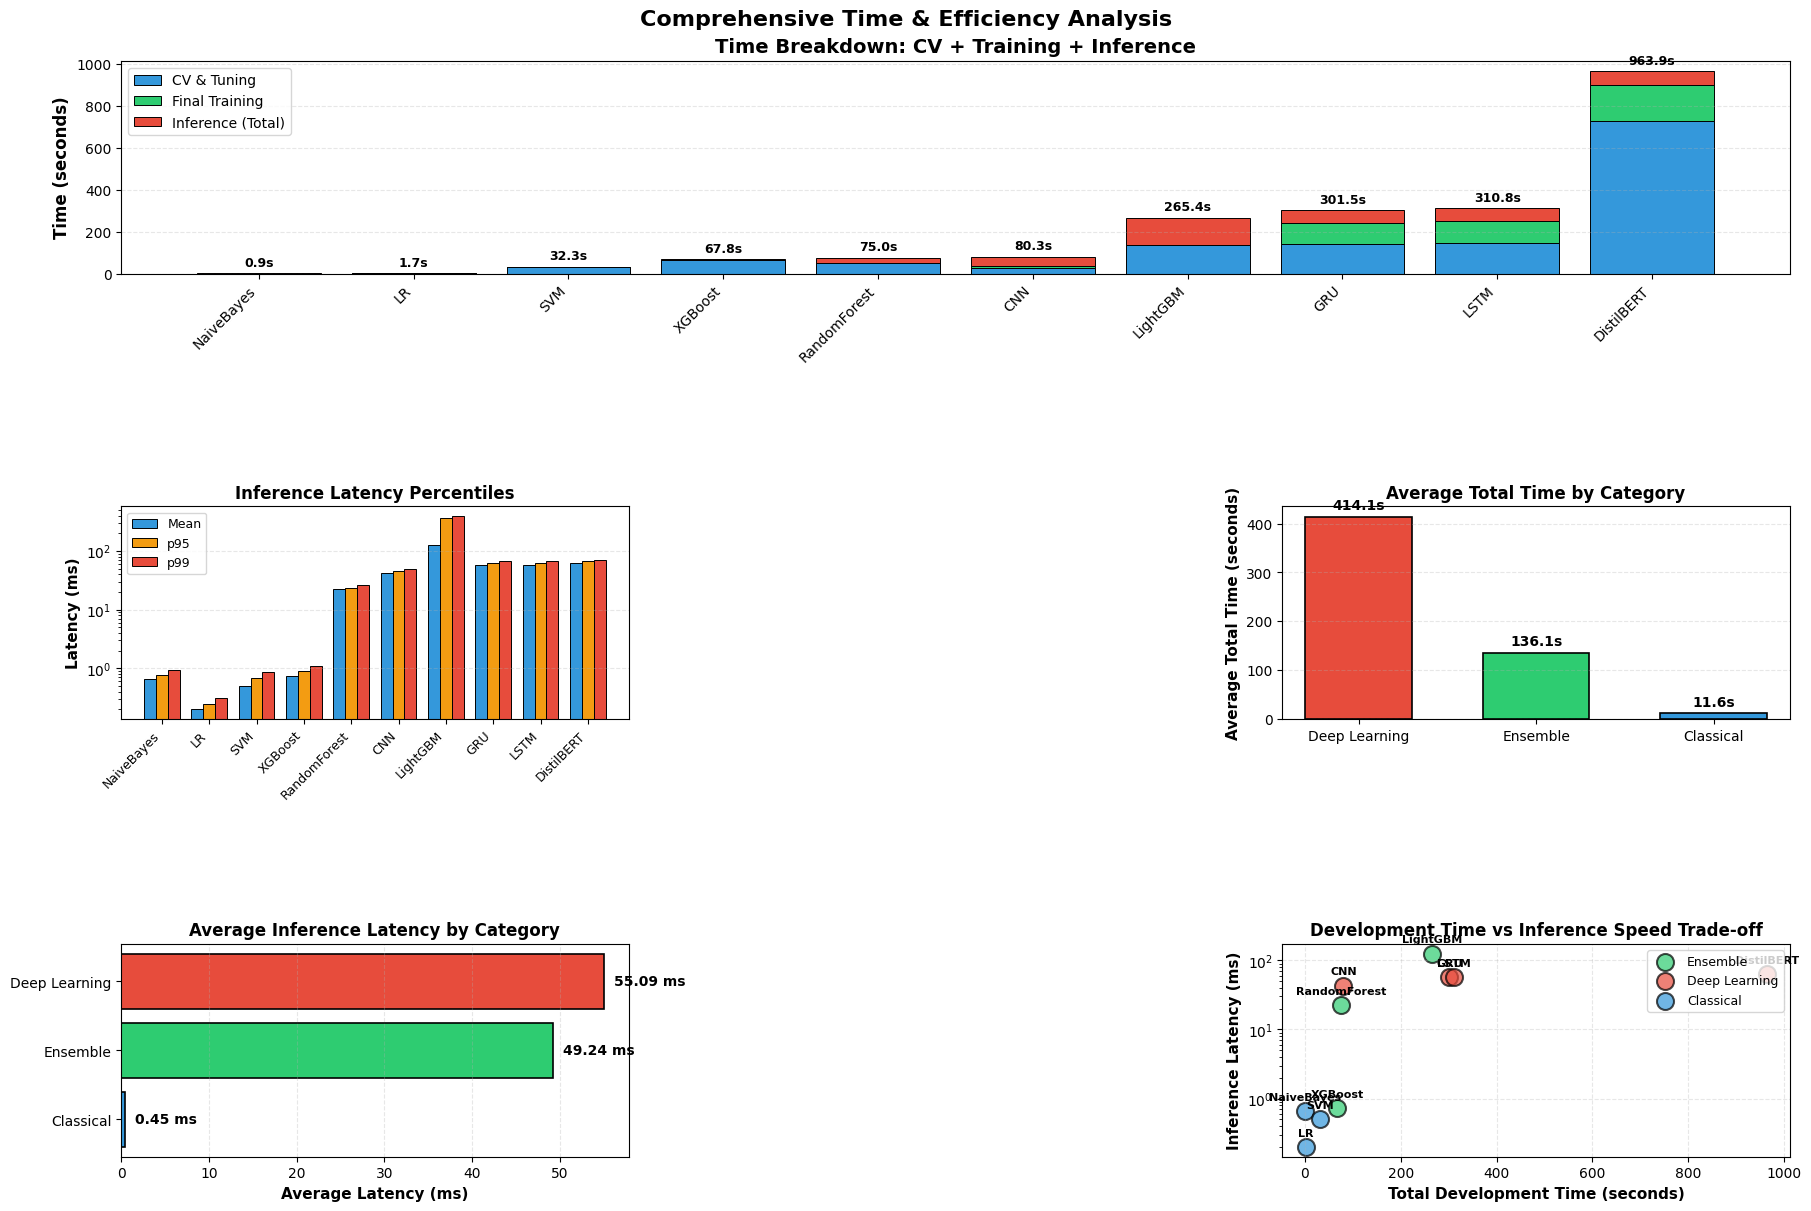


✓ Time analysis visualizations generated successfully!


In [42]:
# ====================================================================================
# HÜCRE 8: COMPREHENSIVE TIME ANALYSIS
# ====================================================================================

print("\n" + "=" * 120)
print("COMPREHENSIVE TIME & EFFICIENCY ANALYSIS")
print("=" * 120)

# Prepare data from model_results
timing_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model": model_name,
        "Category": metrics.get("Category", "Unknown"),
        "CV Time (s)": metrics.get("CV_Time", 0),
        "Training Time (s)": metrics.get("Training_Time", 0),
        "Inference Time (s)": metrics.get("Inference_Time_Sec", 0),
        "Total Time (s)": metrics.get("Total_Time", 0),
        "Latency Mean (ms)": metrics.get("Latency_ms", 0),
        "Latency p95 (ms)": metrics.get("Latency_p95_ms", 0),
        "Latency p99 (ms)": metrics.get("Latency_p99_ms", 0)
    }
    timing_data.append(row)

# Create DataFrame
df_time = pd.DataFrame(timing_data)

# Sort by Total Time
df_time = df_time.sort_values("Total Time (s)", ascending=True).reset_index(drop=True)

# Display table
print("\n📊 DETAILED TIME BREAKDOWN:")
print("-" * 120)
print(df_time.to_string(index=False, float_format="%.4f"))
print("-" * 120)

# Summary statistics
print("\n📈 TIME STATISTICS:")
print(f"   Fastest Total:     {df_time.iloc[0]['Model']:<15} ({df_time.iloc[0]['Total Time (s)']:.2f} s)")
print(f"   Slowest Total:     {df_time.iloc[-1]['Model']:<15} ({df_time.iloc[-1]['Total Time (s)']:.2f} s)")
print(f"   Fastest Inference: {df_time.nsmallest(1, 'Latency Mean (ms)').iloc[0]['Model']:<15} "
      f"({df_time.nsmallest(1, 'Latency Mean (ms)').iloc[0]['Latency Mean (ms)']:.4f} ms)")
print(f"   Slowest Inference: {df_time.nlargest(1, 'Latency Mean (ms)').iloc[0]['Model']:<15} "
      f"({df_time.nlargest(1, 'Latency Mean (ms)').iloc[0]['Latency Mean (ms)']:.4f} ms)")

# Create visualization
fig = plt.figure(figsize=(18, 12), constrained_layout=True)
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Color mapping
category_colors = {
    'Classical': '#3498db',
    'Ensemble': '#2ecc71',
    'Deep Learning': '#e74c3c'
}

# Panel 1: Stacked Time Breakdown (CV + Training + Inference)
ax1 = fig.add_subplot(gs[0, :])
models = df_time['Model'].values
cv_times = df_time['CV Time (s)'].values
train_times = df_time['Training Time (s)'].values
inf_times = df_time['Inference Time (s)'].values

x_pos = np.arange(len(models))
p1 = ax1.bar(x_pos, cv_times, label='CV & Tuning', color='#3498db', edgecolor='black', linewidth=0.7)
p2 = ax1.bar(x_pos, train_times, bottom=cv_times, label='Final Training', 
             color='#2ecc71', edgecolor='black', linewidth=0.7)
p3 = ax1.bar(x_pos, inf_times, bottom=cv_times+train_times, label='Inference (Total)', 
             color='#e74c3c', edgecolor='black', linewidth=0.7)

ax1.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Time Breakdown: CV + Training + Inference', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add total time labels on top
for i, (cv, tr, inf) in enumerate(zip(cv_times, train_times, inf_times)):
    total = cv + tr + inf
    ax1.text(i, total + max(cv_times+train_times+inf_times)*0.02, f'{total:.1f}s', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 2: Latency Percentiles Comparison
ax2 = fig.add_subplot(gs[1, 0])
lat_mean = df_time['Latency Mean (ms)'].values
lat_p95 = df_time['Latency p95 (ms)'].values
lat_p99 = df_time['Latency p99 (ms)'].values

x_pos2 = np.arange(len(models))
width = 0.25

bars1 = ax2.bar(x_pos2 - width, lat_mean, width, label='Mean', 
                color='#3498db', edgecolor='black', linewidth=0.7)
bars2 = ax2.bar(x_pos2, lat_p95, width, label='p95', 
                color='#f39c12', edgecolor='black', linewidth=0.7)
bars3 = ax2.bar(x_pos2 + width, lat_p99, width, label='p99', 
                color='#e74c3c', edgecolor='black', linewidth=0.7)

ax2.set_ylabel('Latency (ms)', fontsize=11, fontweight='bold')
ax2.set_title('Inference Latency Percentiles', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos2)
ax2.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax2.legend(loc='upper left', fontsize=9)
ax2.set_yscale('log')  # Log scale for better visibility
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Panel 3: Category-wise Total Time Comparison
ax3 = fig.add_subplot(gs[1, 1])
category_time = df_time.groupby('Category')['Total Time (s)'].mean().sort_values(ascending=False)
colors_cat = [category_colors.get(cat, '#95a5a6') for cat in category_time.index]

bars_cat = ax3.bar(category_time.index, category_time.values, color=colors_cat,
                   edgecolor='black', linewidth=1.2, width=0.6)
ax3.set_ylabel('Average Total Time (seconds)', fontsize=11, fontweight='bold')
ax3.set_title('Average Total Time by Category', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for i, v in enumerate(category_time.values):
    ax3.text(i, v + max(category_time.values)*0.02, f'{v:.1f}s', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel 4: Category-wise Inference Latency
ax4 = fig.add_subplot(gs[2, 0])
category_latency = df_time.groupby('Category')['Latency Mean (ms)'].mean().sort_values(ascending=True)
colors_cat2 = [category_colors.get(cat, '#95a5a6') for cat in category_latency.index]

bars_lat = ax4.barh(category_latency.index, category_latency.values, color=colors_cat2,
                    edgecolor='black', linewidth=1.2)
ax4.set_xlabel('Average Latency (ms)', fontsize=11, fontweight='bold')
ax4.set_title('Average Inference Latency by Category', fontsize=12, fontweight='bold')
ax4.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, v in enumerate(category_latency.values):
    ax4.text(v + max(category_latency.values)*0.02, i, f'{v:.2f} ms', 
            va='center', fontsize=10, fontweight='bold')

# Panel 5: Efficiency Matrix (Time vs Latency)
ax5 = fig.add_subplot(gs[2, 1])
for category in set(df_time['Category']):
    mask = df_time['Category'] == category
    ax5.scatter(df_time[mask]['Total Time (s)'], 
               df_time[mask]['Latency Mean (ms)'],
               s=150, alpha=0.7, 
               color=category_colors.get(category, '#95a5a6'),
               edgecolors='black', linewidth=1.5, 
               label=category)
    
    # Add labels
    for _, row in df_time[mask].iterrows():
        ax5.annotate(row['Model'], 
                    (row['Total Time (s)'], row['Latency Mean (ms)']),
                    textcoords="offset points", xytext=(0, 8),
                    ha='center', fontsize=8, fontweight='bold')

ax5.set_xlabel('Total Development Time (seconds)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Inference Latency (ms)', fontsize=11, fontweight='bold')
ax5.set_title('Development Time vs Inference Speed Trade-off', fontsize=12, fontweight='bold')
ax5.set_yscale('log')
ax5.legend(loc='upper right', fontsize=9)
ax5.grid(True, alpha=0.3, linestyle='--')

plt.suptitle('Comprehensive Time & Efficiency Analysis', fontsize=16, fontweight='bold')
plt.savefig('comprehensive_time_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Time analysis visualizations generated successfully!")
print("=" * 120)

### 9. Overfitting Analysis


OVERFITTING & GENERALIZATION ANALYSIS

📊 GENERALIZATION PERFORMANCE:
------------------------------------------------------------------------------------------------------------------------
       Model      Category  Train Accuracy  Test Accuracy  Generalization Gap  CV Accuracy Mean  CV Accuracy Std Risk Level
RandomForest      Ensemble          0.9826         0.9778              0.0048            0.9229           0.0049      ✅ LOW
  DistilBERT Deep Learning          0.9981         0.9913              0.0068            0.9886           0.0029      ✅ LOW
     XGBoost      Ensemble          0.9918         0.9807              0.0111            0.9814           0.0031      ✅ LOW
         GRU Deep Learning          1.0000         0.9855              0.0145            0.9826           0.0031      ✅ LOW
    LightGBM      Ensemble          0.9940         0.9787              0.0152            0.9814           0.0031      ✅ LOW
         CNN Deep Learning          0.9983         0.9826        

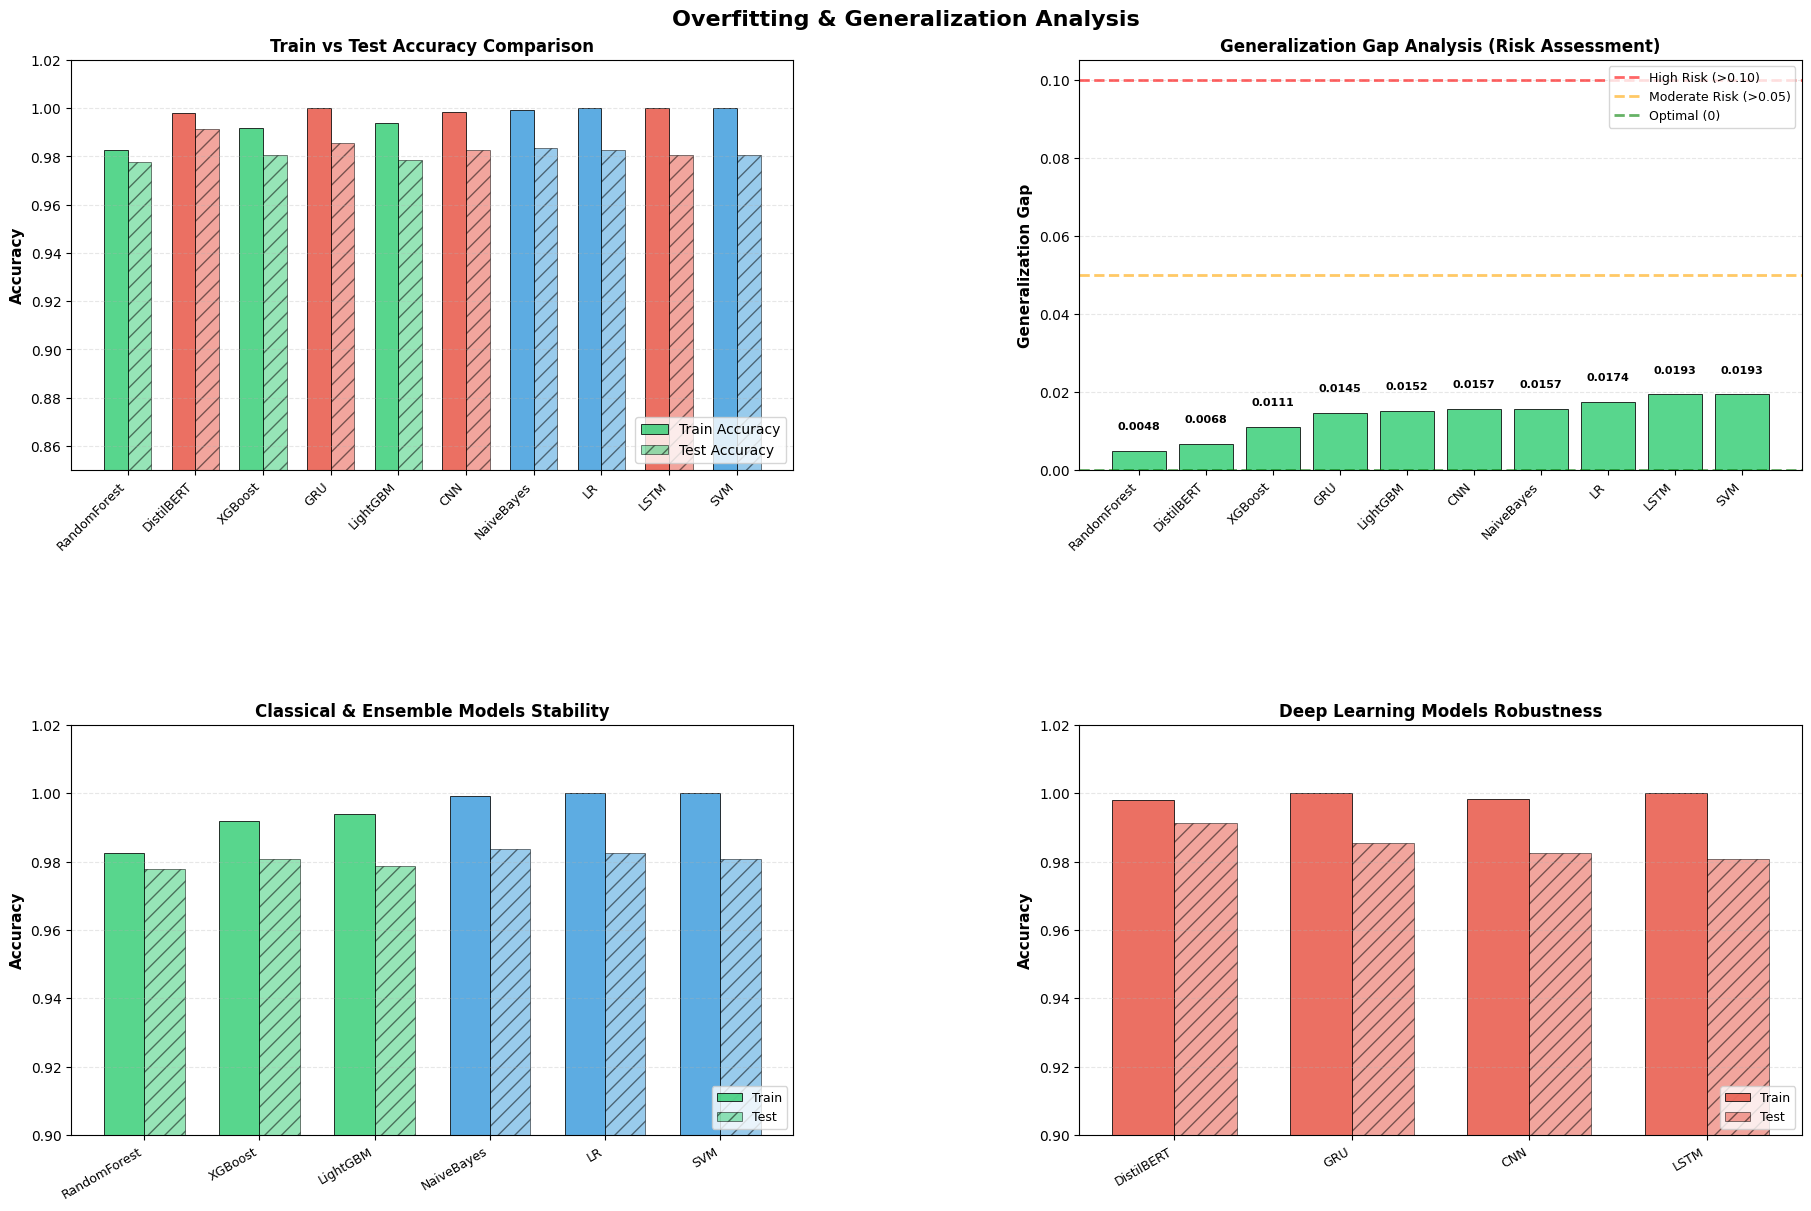


✓ Overfitting analysis visualizations generated successfully!


In [43]:
# ====================================================================================
# HÜCRE 9: OVERFITTING & GENERALIZATION ANALYSIS
# ====================================================================================

print("\n" + "=" * 120)
print("OVERFITTING & GENERALIZATION ANALYSIS")
print("=" * 120)

# Prepare data from model_results (DIREKT SÖZLÜKTEN!)
overfitting_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model": model_name,
        "Category": metrics.get("Category", "Unknown"),
        "Train Accuracy": metrics.get("Train_Accuracy", 0),
        "Test Accuracy": metrics.get("Test_Accuracy", 0),
        "Generalization Gap": metrics.get("Generalization_Gap", 0),
        "CV Accuracy Mean": metrics.get("CV_Accuracy_Mean", 0),
        "CV Accuracy Std": metrics.get("CV_Accuracy_Std", 0)
    }
    overfitting_data.append(row)

# Create DataFrame
df_overfit = pd.DataFrame(overfitting_data)

# Sort by Generalization Gap (ascending - lower is better)
df_overfit = df_overfit.sort_values("Generalization Gap", ascending=True).reset_index(drop=True)

# Risk classification
df_overfit['Risk Level'] = df_overfit['Generalization Gap'].apply(
    lambda x: "🚨 HIGH" if x > 0.10 else ("⚠️ MODERATE" if x > 0.05 else "✅ LOW")
)

# Display table
print("\n📊 GENERALIZATION PERFORMANCE:")
print("-" * 120)
print(df_overfit.to_string(index=False, float_format="%.4f"))
print("-" * 120)

# Summary statistics
print("\n📈 OVERFITTING STATISTICS:")
print(f"   Best Generalization:  {df_overfit.iloc[0]['Model']:<15} (Gap: {df_overfit.iloc[0]['Generalization Gap']:.4f})")
print(f"   Worst Generalization: {df_overfit.iloc[-1]['Model']:<15} (Gap: {df_overfit.iloc[-1]['Generalization Gap']:.4f})")
print(f"   Average Gap:          {df_overfit['Generalization Gap'].mean():.4f}")
print(f"   High Risk Models:     {len(df_overfit[df_overfit['Generalization Gap'] > 0.10])}")
print(f"   Low Risk Models:      {len(df_overfit[df_overfit['Generalization Gap'] <= 0.05])}")

# Category-wise summary
print("\n📊 CATEGORY-WISE GENERALIZATION:")
category_summary = df_overfit.groupby('Category').agg({
    'Generalization Gap': ['mean', 'std', 'min', 'max']
}).round(4)
print(category_summary)

# Create visualization
fig = plt.figure(figsize=(18, 12), constrained_layout=True)
gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.25)

# Color mapping
category_colors = {
    'Classical': '#3498db',
    'Ensemble': '#2ecc71',
    'Deep Learning': '#e74c3c'
}

# Panel 1: Train vs Test Accuracy
ax1 = fig.add_subplot(gs[0, 0])
x_pos = np.arange(len(df_overfit))
width = 0.35

colors_train = [category_colors.get(cat, '#95a5a6') for cat in df_overfit['Category']]
colors_test = colors_train  # Same colors

bars1 = ax1.bar(x_pos - width/2, df_overfit['Train Accuracy'], width, 
                label='Train Accuracy', color=colors_train, alpha=0.8, 
                edgecolor='black', linewidth=0.7)
bars2 = ax1.bar(x_pos + width/2, df_overfit['Test Accuracy'], width, 
                label='Test Accuracy', color=colors_test, alpha=0.5, 
                edgecolor='black', linewidth=0.7, hatch='//')

ax1.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Train vs Test Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_overfit['Model'], rotation=45, ha='right', fontsize=9)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim([0.85, 1.02])

# Panel 2: Generalization Gap (Color-coded by Risk)
ax2 = fig.add_subplot(gs[0, 1])
gap_colors = ['#e74c3c' if g > 0.10 else '#f39c12' if g > 0.05 else '#2ecc71' 
              for g in df_overfit['Generalization Gap']]

bars_gap = ax2.bar(df_overfit['Model'], df_overfit['Generalization Gap'], 
                   color=gap_colors, edgecolor='black', linewidth=0.7, alpha=0.8)

ax2.set_ylabel('Generalization Gap', fontsize=11, fontweight='bold')
ax2.set_title('Generalization Gap Analysis (Risk Assessment)', fontsize=12, fontweight='bold')
ax2.set_xticklabels(df_overfit['Model'], rotation=45, ha='right', fontsize=9)

# Risk threshold lines
ax2.axhline(y=0.10, color='red', linestyle='--', linewidth=2, alpha=0.6, label='High Risk (>0.10)')
ax2.axhline(y=0.05, color='orange', linestyle='--', linewidth=2, alpha=0.6, label='Moderate Risk (>0.05)')
ax2.axhline(y=0.00, color='green', linestyle='--', linewidth=2, alpha=0.6, label='Optimal (0)')

ax2.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for i, v in enumerate(df_overfit['Generalization Gap']):
    ax2.text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Panel 3: Classical & Ensemble Breakdown
ax3 = fig.add_subplot(gs[1, 0])
df_classical_ensemble = df_overfit[df_overfit['Category'].isin(['Classical', 'Ensemble'])]

if not df_classical_ensemble.empty:
    x_ce = np.arange(len(df_classical_ensemble))
    colors_ce = [category_colors.get(cat, '#95a5a6') for cat in df_classical_ensemble['Category']]
    
    bars_ce_train = ax3.bar(x_ce - width/2, df_classical_ensemble['Train Accuracy'], width, 
                            label='Train', color=colors_ce, alpha=0.8, edgecolor='black', linewidth=0.7)
    bars_ce_test = ax3.bar(x_ce + width/2, df_classical_ensemble['Test Accuracy'], width, 
                           label='Test', color=colors_ce, alpha=0.5, edgecolor='black', 
                           linewidth=0.7, hatch='//')
    
    ax3.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax3.set_title('Classical & Ensemble Models Stability', fontsize=12, fontweight='bold')
    ax3.set_xticks(x_ce)
    ax3.set_xticklabels(df_classical_ensemble['Model'], rotation=30, ha='right', fontsize=9)
    ax3.legend(loc='lower right', fontsize=9)
    ax3.grid(axis='y', alpha=0.3, linestyle='--')
    ax3.set_ylim([0.90, 1.02])

# Panel 4: Deep Learning Breakdown
ax4 = fig.add_subplot(gs[1, 1])
df_dl = df_overfit[df_overfit['Category'] == 'Deep Learning']

if not df_dl.empty:
    x_dl = np.arange(len(df_dl))
    color_dl = category_colors.get('Deep Learning', '#e74c3c')
    
    bars_dl_train = ax4.bar(x_dl - width/2, df_dl['Train Accuracy'], width, 
                           label='Train', color=color_dl, alpha=0.8, edgecolor='black', linewidth=0.7)
    bars_dl_test = ax4.bar(x_dl + width/2, df_dl['Test Accuracy'], width, 
                          label='Test', color=color_dl, alpha=0.5, edgecolor='black', 
                          linewidth=0.7, hatch='//')
    
    ax4.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax4.set_title('Deep Learning Models Robustness', fontsize=12, fontweight='bold')
    ax4.set_xticks(x_dl)
    ax4.set_xticklabels(df_dl['Model'], rotation=30, ha='right', fontsize=9)
    ax4.legend(loc='lower right', fontsize=9)
    ax4.grid(axis='y', alpha=0.3, linestyle='--')
    ax4.set_ylim([0.90, 1.02])

plt.suptitle('Overfitting & Generalization Analysis', fontsize=16, fontweight='bold')
plt.savefig('overfitting_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Overfitting analysis visualizations generated successfully!")
print("=" * 120)

### 10. ALL CONFUSION MATRICES


 Final styled confusion matrices saved as 'confusion_matrices_final_styled.png'


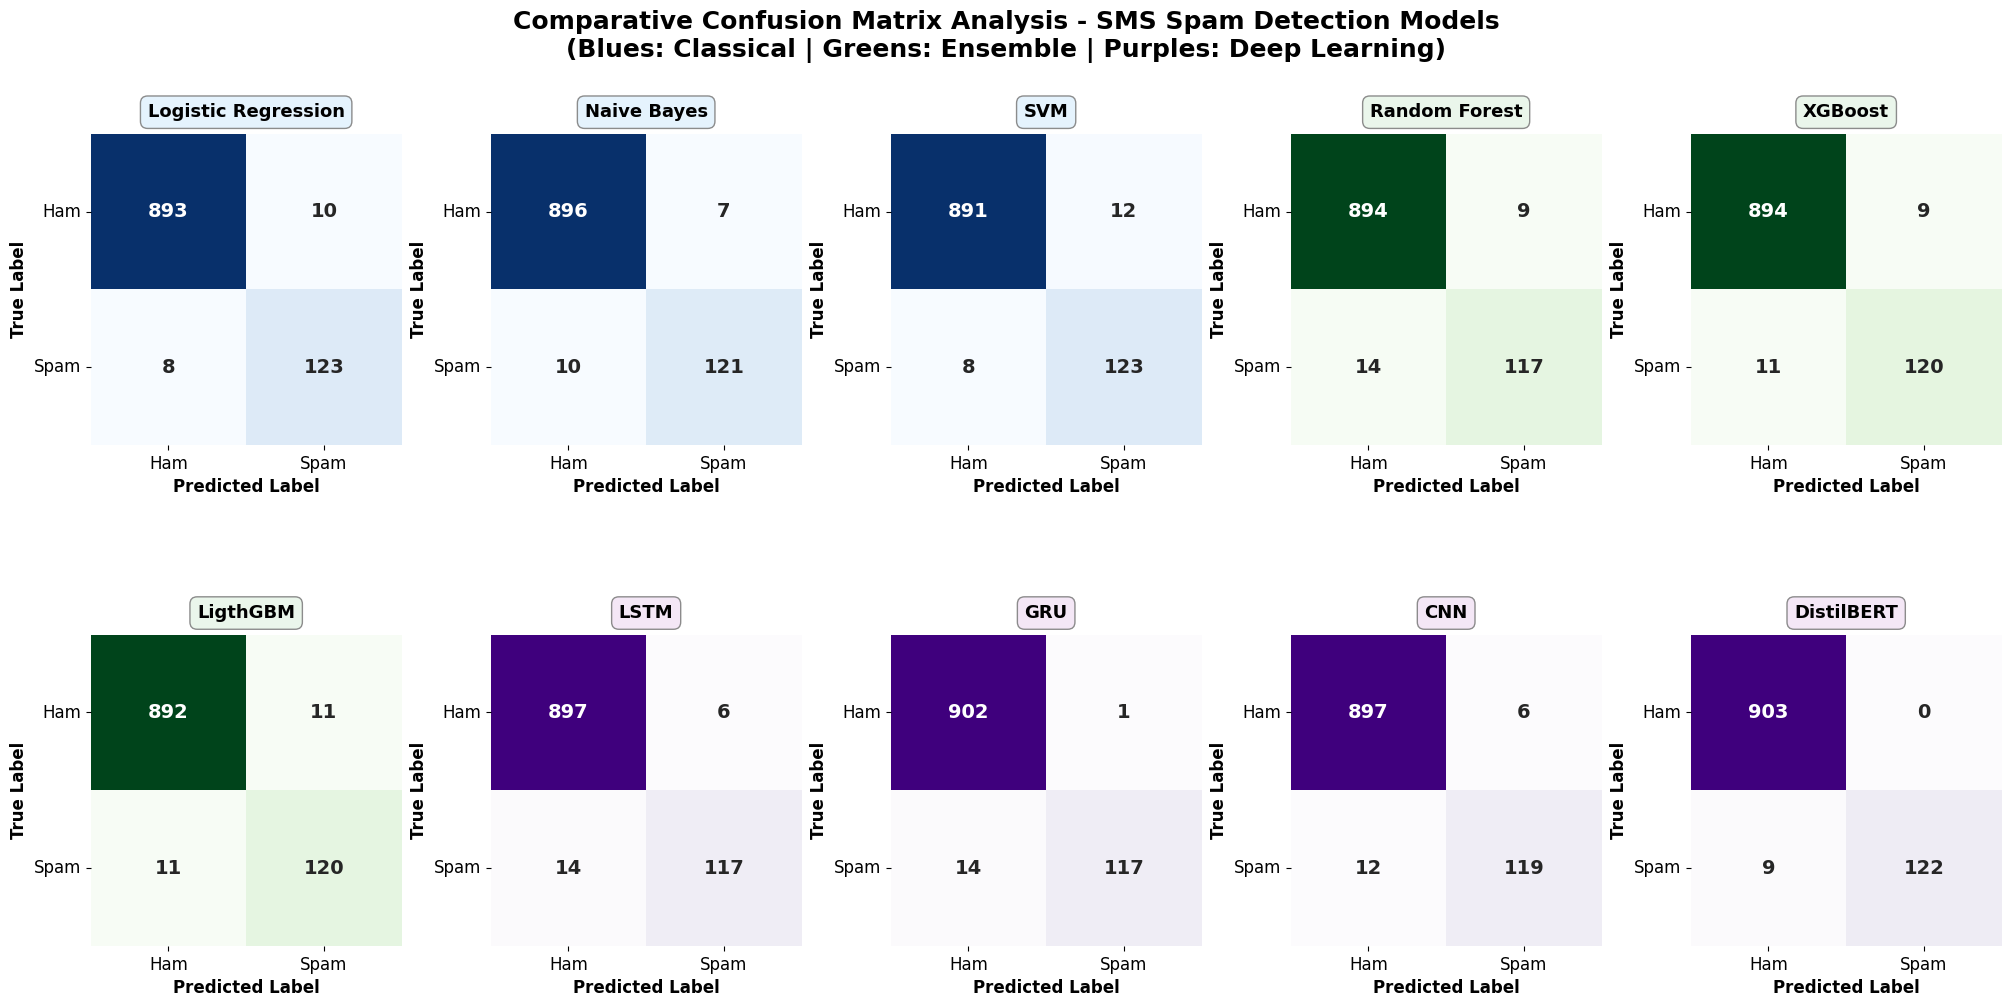

In [56]:
# =============================================================================
# CELL 18: ALL CONFUSION MATRICES - CATEGORIZED BY COLOR (FINAL 10 MODELS)
# =============================================================================

# 1. Memory Cleanup and Layout Settings
plt.close('all')

# 2. Define Final 10 Models (Mapped to SMS Spam Project Variables)
model_map_config = [
    # Classical (Blue)
    ("Logistic Regression", "best_lr_predict",  "Classical"),
    ("Naive Bayes",         "best_nb_predict",  "Classical"),
    ("SVM",                 "best_svm_predict", "Classical"),
    
    # Ensemble (Green)
    ("Random Forest",       "best_rf_predict",  "Ensemble"),
    ("XGBoost",             "best_xgb_predict", "Ensemble"),
    ("LigthGBM",            "best_lgbm_predict", "Ensemble"),
 
    # Deep Learning (Purple)
    ("LSTM",                "best_lstm_predict", "Deep Learning"),
    ("GRU",                 "best_gru_predict",  "Deep Learning"),
    ("CNN",                 "best_cnn_predict",  "Deep Learning"),
    ("DistilBERT",          "best_bert_predict", "Deep Learning")
]

# Check for active models in memory to avoid errors
active_models = []
for name, var_name, category in model_map_config:
    if var_name in globals():
        active_models.append((name, globals()[var_name], category))
    else:
        print(f" {name} skipped (Not trained yet).")

if not active_models:
    print(" ERROR: No model results found in memory.")
else:
    # 3. Dynamic Grid Setup
    num_models = len(active_models)
    cols = 5  # Optimized for 10 models (2 Rows x 5 Columns)
    rows = (num_models // cols) + (1 if num_models % cols > 0 else 0)
    
    # Adjusted figsize to match the template's proportions
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows), layout='constrained')
    axes = axes.ravel() 
    
    # 4. Color Palettes and Themes (Template Style)
    category_colors = {
        'Classical': 'Blues',
        'Ensemble': 'Greens', 
        'Deep Learning': 'Purples' # Template requested Purples
    }
    
    background_colors = {
        'Classical': '#E3F2FD', 
        'Ensemble': '#E8F5E9', 
        'Deep Learning': '#F3E5F5'
    }

    # 5. Drawing Loop
    for idx, (name, pred, category) in enumerate(active_models):
        y_true = y_test 
        
        # Flatten deep learning predictions if necessary
        if hasattr(pred, "ndim") and pred.ndim > 1: 
            pred = pred.flatten()
        
        cm = confusion_matrix(y_true, pred)
        
        # Heatmap plotting (Template styling)
        sns.heatmap(cm, annot=True, fmt='d', cmap=category_colors[category], 
                    ax=axes[idx], cbar=False, square=True, 
                    annot_kws={'size': 14, 'weight': 'bold'}) # Font size 14 as per template style
        
        # Title and Header Style (Rounded Box)
        axes[idx].set_title(f'{name}', 
                            fontsize=13, fontweight='bold', pad=12,
                            bbox=dict(boxstyle='round,pad=0.4', 
                                      facecolor=background_colors[category],
                                      edgecolor='gray',
                                      alpha=0.9))
                                      
        axes[idx].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('True Label', fontsize=12, fontweight='bold')
        
        # Labels: Ham vs Spam
        axes[idx].set_xticklabels(['Ham', 'Spam'], fontsize=12)
        axes[idx].set_yticklabels(['Ham', 'Spam'], fontsize=12, rotation=0)

    # 6. Hide empty subplots
    for i in range(num_models, len(axes)):
        axes[i].axis('off')

    # 7. Final Suptitle and Save
    plt.suptitle('Comparative Confusion Matrix Analysis - SMS Spam Detection Models\n(Blues: Classical | Greens: Ensemble | Purples: Deep Learning)', 
                 fontsize=18, fontweight='bold', y=1.03)

    try:
        plt.savefig('confusion_matrices_final_styled.png', dpi=300, bbox_inches='tight')
        print("\n Final styled confusion matrices saved as 'confusion_matrices_final_styled.png'")
    except Exception as e:
        print(f"\n Save failed: {e}")

    plt.show()

# 11. Radar Chart


GENERATING CATEGORY-WISE RADAR CHARTS (Performance + Efficiency)
✓ Radar chart saved as 'radar_chart_category_comparison.png'


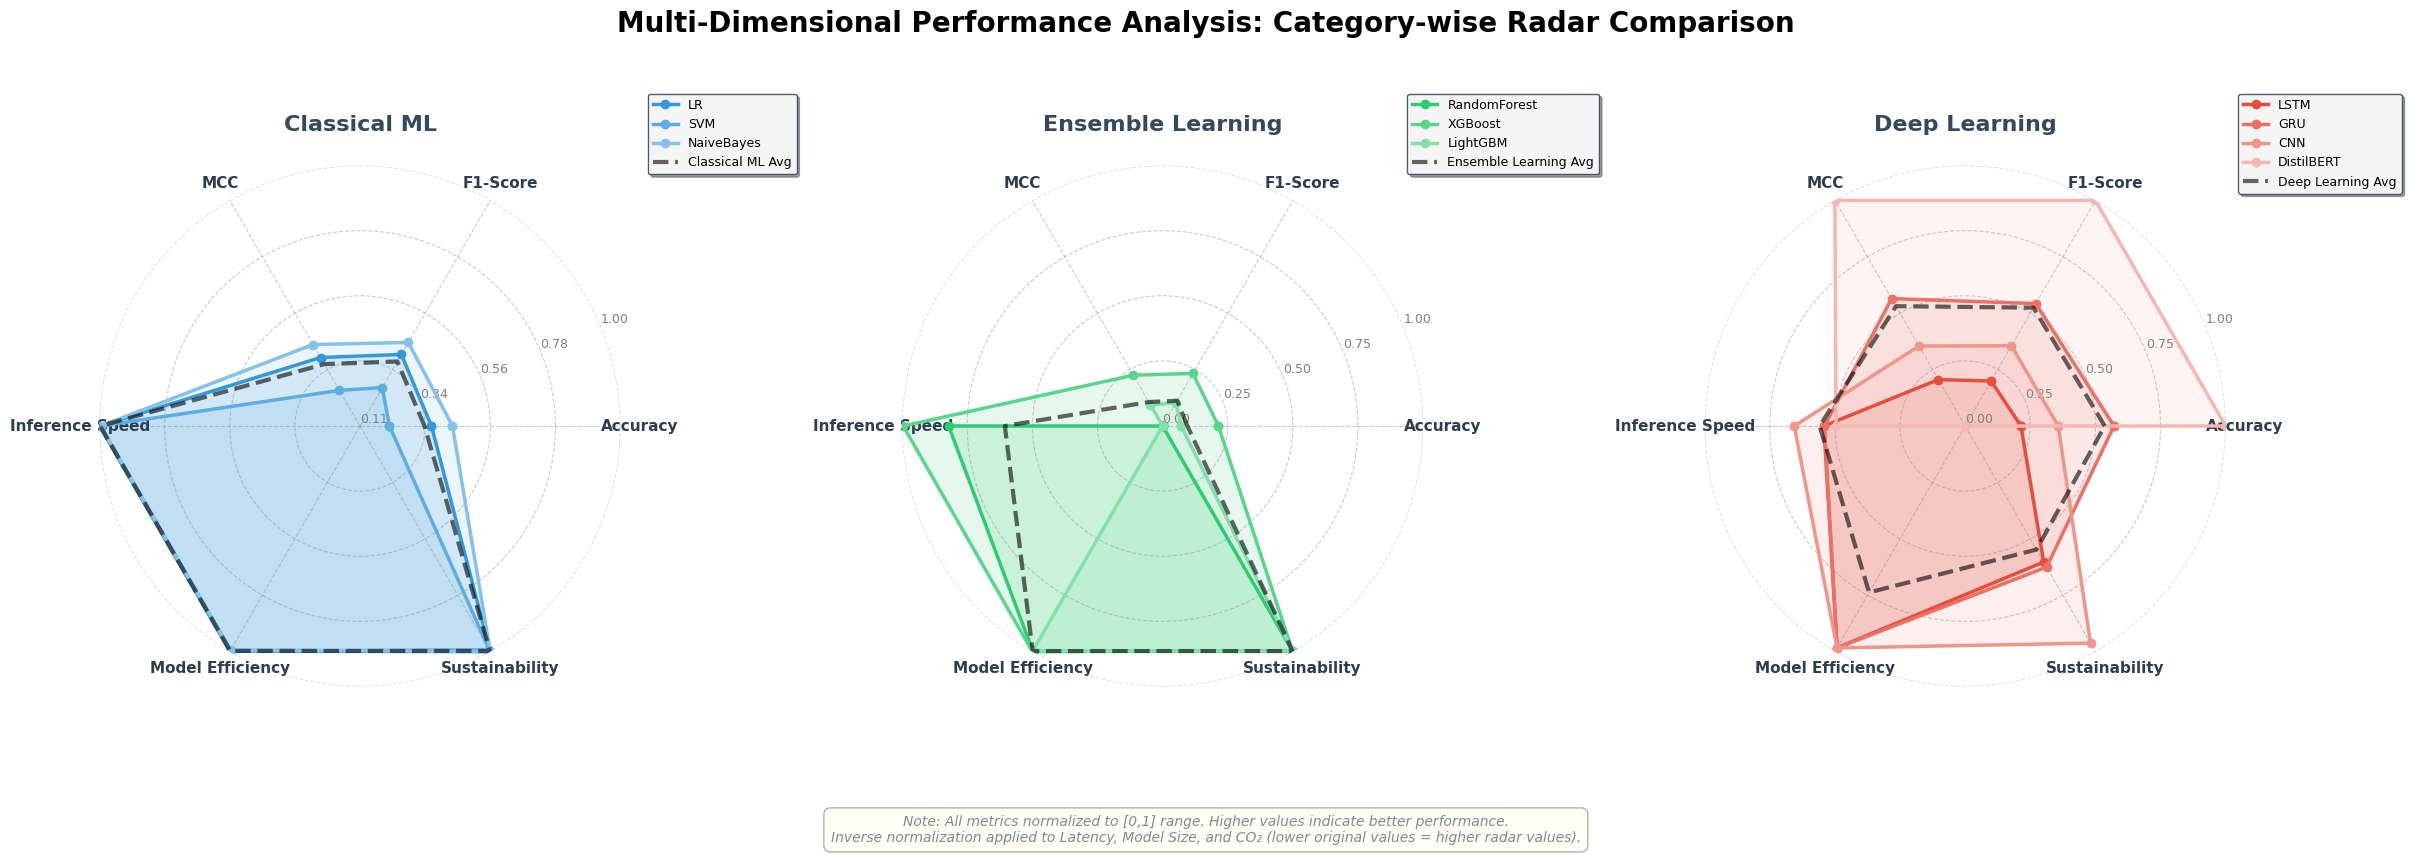


📊 CATEGORY-WISE AVERAGE SCORES (Normalized 0-1):
------------------------------------------------------------------------------------------------------------------------
Category                  Accuracy     F1-Score     MCC          Inf.Speed    Efficiency   Sustainability
------------------------------------------------------------------------------------------------------------------------
Classical ML              0.3333       0.3677       0.3571       0.9979       0.9972       0.9976      
Ensemble Learning         0.0952       0.1119       0.1062       0.6057       0.9978       0.9977      
Deep Learning             0.5357       0.5244       0.5312       0.5587       0.7377       0.5478      
------------------------------------------------------------------------------------------------------------------------

🏆 BEST OVERALL CATEGORY: Classical ML (Avg Score: 0.6752)


In [46]:
# ====================================================================================
# RADAR CHART - CATEGORY-WISE MULTI-DIMENSIONAL COMPARISON
# ====================================================================================

print("\n" + "=" * 120)
print("GENERATING CATEGORY-WISE RADAR CHARTS (Performance + Efficiency)")
print("=" * 120)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Close any existing plots
plt.close('all')

# ================================================================================
# 1. DATA PREPARATION & NORMALIZATION
# ================================================================================

# Define categories and their models
categories_dict = {
    'Classical ML': ['LR', 'SVM', 'NaiveBayes'],
    'Ensemble Learning': ['RandomForest', 'XGBoost', 'LightGBM'],
    'Deep Learning': ['LSTM', 'GRU', 'CNN', 'DistilBERT']
}

# Academic color palette (consistent with previous charts)
category_colors = {
    'Classical ML': ['#3498db', '#5dade2', '#85c1e9'],
    'Ensemble Learning': ['#2ecc71', '#58d68d', '#82e0aa'],
    'Deep Learning': ['#e74c3c', '#ec7063', '#f1948a', '#f5b7b1']
}

# Metrics to display (6 dimensions for balance)
metrics_labels = [
    "Accuracy",
    "F1-Score",
    "MCC",
    "Inference Speed",
    "Model Efficiency",
    "Sustainability"
]

N = len(metrics_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Close the loop

# ================================================================================
# 2. COLLECT AND NORMALIZE DATA
# ================================================================================

# Collect all raw values first (for global normalization)
all_metrics = {
    'Accuracy': [],
    'F1_Score': [],
    'MCC': [],
    'Latency_ms': [],
    'Model_Size_MB': [],
    'CO2_emissions_kg': []
}

for category_models in categories_dict.values():
    for model_name in category_models:
        if model_name in model_results:
            stats = model_results[model_name]
            all_metrics['Accuracy'].append(stats.get('Accuracy', 0))
            all_metrics['F1_Score'].append(stats.get('F1_Score', 0))
            all_metrics['MCC'].append(stats.get('MCC', 0))
            all_metrics['Latency_ms'].append(stats.get('Latency_ms', 0))
            all_metrics['Model_Size_MB'].append(stats.get('Model_Size_MB', 0))
            all_metrics['CO2_emissions_kg'].append(stats.get('CO2_emissions_kg', 0))

# Calculate min/max for normalization
def safe_min_max(values):
    """Return min and max, handling empty or single-value lists"""
    if not values:
        return 0, 1
    if len(values) == 1:
        return values[0], values[0] + 0.01
    return min(values), max(values)

acc_min, acc_max = safe_min_max(all_metrics['Accuracy'])
f1_min, f1_max = safe_min_max(all_metrics['F1_Score'])
mcc_min, mcc_max = safe_min_max(all_metrics['MCC'])
lat_min, lat_max = safe_min_max(all_metrics['Latency_ms'])
size_min, size_max = safe_min_max(all_metrics['Model_Size_MB'])
co2_min, co2_max = safe_min_max(all_metrics['CO2_emissions_kg'])

# Normalization function
def normalize_metric(value, min_val, max_val, inverse=False):
    """Normalize value to [0, 1] range. If inverse=True, lower is better."""
    if max_val == min_val:
        return 0.5
    
    normalized = (value - min_val) / (max_val - min_val)
    
    if inverse:
        normalized = 1 - normalized  # Invert for metrics where lower is better
    
    return np.clip(normalized, 0, 1)

# ================================================================================
# 3. FIGURE SETUP
# ================================================================================

fig, axes = plt.subplots(1, 3, figsize=(24, 8), 
                         subplot_kw=dict(projection='polar'),
                         constrained_layout=True)

# ================================================================================
# 4. PLOTTING LOOP
# ================================================================================

category_stats = {}  # Store for summary statistics

for ax, (category_name, model_list) in zip(axes, categories_dict.items()):
    
    colors = category_colors[category_name]
    category_values_all = []  # For category average
    
    for idx, model_name in enumerate(model_list):
        
        if model_name not in model_results:
            continue
        
        stats = model_results[model_name]
        
        # Extract and normalize values
        accuracy = normalize_metric(stats.get('Accuracy', 0), acc_min, acc_max)
        f1_score = normalize_metric(stats.get('F1_Score', 0), f1_min, f1_max)
        mcc = normalize_metric(stats.get('MCC', 0), mcc_min, mcc_max)
        
        # Inverse normalization for efficiency metrics (lower = better)
        latency = normalize_metric(stats.get('Latency_ms', 0), lat_min, lat_max, inverse=True)
        model_size = normalize_metric(stats.get('Model_Size_MB', 0), size_min, size_max, inverse=True)
        co2 = normalize_metric(stats.get('CO2_emissions_kg', 0), co2_min, co2_max, inverse=True)
        
        # Create values list
        values = [accuracy, f1_score, mcc, latency, model_size, co2]
        values += values[:1]  # Close the loop
        
        category_values_all.append(values[:-1])  # Store for average (without duplicate)
        
        # Safety check for color index
        color = colors[idx % len(colors)]
        
        # Plot line
        ax.plot(angles, values, label=model_name, linewidth=2.5,
               color=color, marker='o', markersize=6)
        
        # Fill area with transparency
        ax.fill(angles, values, alpha=0.15, color=color)
    
    # Calculate category average
    if category_values_all:
        category_avg = np.mean(category_values_all, axis=0).tolist()
        category_avg += category_avg[:1]  # Close loop
        category_stats[category_name] = category_avg[:-1]
        
        # Plot category average as bold dashed line
        ax.plot(angles, category_avg, linewidth=3, linestyle='--',
               color='black', alpha=0.6, label=f'{category_name} Avg')
    
    # ================================================================================
    # 5. AXIS FORMATTING
    # ================================================================================
    
    # Set metric labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_labels, fontsize=11, fontweight='bold', color='#2c3e50')
    
    # Dynamic Y-axis range (based on data)
    if category_values_all:
        all_vals = np.array(category_values_all).flatten()
        y_min = max(0.0, np.min(all_vals) - 0.1)
        y_max = min(1.0, np.max(all_vals) + 0.05)
    else:
        y_min, y_max = 0.0, 1.0
    
    ax.set_ylim(y_min, y_max)
    
    # Y-axis ticks
    y_ticks = np.linspace(y_min, y_max, 5)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{y:.2f}' for y in y_ticks], color='gray', size=9)
    
    # Grid styling
    ax.grid(True, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
    
    # Remove polar spine for cleaner look
    ax.spines['polar'].set_visible(False)
    
    # Title
    ax.set_title(category_name, fontsize=16, fontweight='bold', 
                pad=25, color='#34495e')
    
    # Legend
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
             fontsize=9, frameon=True, fancybox=True, shadow=True,
             edgecolor='#34495e', framealpha=0.9)

# ================================================================================
# 6. OVERALL TITLE & ANNOTATIONS
# ================================================================================

plt.suptitle('Multi-Dimensional Performance Analysis: Category-wise Radar Comparison',
            fontsize=20, fontweight='bold', y=1.02)

# Add note about normalization
fig.text(0.5, -0.02, 
         'Note: All metrics normalized to [0,1] range. Higher values indicate better performance.\n'
         'Inverse normalization applied to Latency, Model Size, and CO₂ (lower original values = higher radar values).',
         ha='center', fontsize=10, style='italic', color='#7f8c8d',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.3))

# ================================================================================
# 7. SAVE & DISPLAY
# ================================================================================

plt.savefig('radar_chart_category_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Radar chart saved as 'radar_chart_category_comparison.png'")

plt.show()

# ================================================================================
# 8. PRINT CATEGORY STATISTICS
# ================================================================================

print("\n📊 CATEGORY-WISE AVERAGE SCORES (Normalized 0-1):")
print("-" * 120)
print(f"{'Category':<25} {'Accuracy':<12} {'F1-Score':<12} {'MCC':<12} "
      f"{'Inf.Speed':<12} {'Efficiency':<12} {'Sustainability':<12}")
print("-" * 120)

for cat_name, avg_values in category_stats.items():
    print(f"{cat_name:<25} {avg_values[0]:<12.4f} {avg_values[1]:<12.4f} "
          f"{avg_values[2]:<12.4f} {avg_values[3]:<12.4f} "
          f"{avg_values[4]:<12.4f} {avg_values[5]:<12.4f}")

print("-" * 120)

# Overall champion category
overall_scores = {cat: np.mean(vals) for cat, vals in category_stats.items()}
champion_cat = max(overall_scores, key=overall_scores.get)

print(f"\n🏆 BEST OVERALL CATEGORY: {champion_cat} (Avg Score: {overall_scores[champion_cat]:.4f})")
print("=" * 120)